Found 50 energy files between 1e+01 and 1e+06 GeV:
  E=1.12202e1 (1.122e+01 GeV)
  E=1.41254e1 (1.413e+01 GeV)
  E=1.77828e1 (1.778e+01 GeV)
  E=2.23872e1 (2.239e+01 GeV)
  E=2.81838e1 (2.818e+01 GeV)
  E=3.54813e1 (3.548e+01 GeV)
  E=4.46684e1 (4.467e+01 GeV)
  E=5.62341e1 (5.623e+01 GeV)
  E=7.07946e1 (7.079e+01 GeV)
  E=8.91251e1 (8.913e+01 GeV)
  E=1.12202e2 (1.122e+02 GeV)
  E=1.41254e2 (1.413e+02 GeV)
  E=1.77828e2 (1.778e+02 GeV)
  E=2.23872e2 (2.239e+02 GeV)
  E=2.81838e2 (2.818e+02 GeV)
  E=3.54813e2 (3.548e+02 GeV)
  E=4.46684e2 (4.467e+02 GeV)
  E=5.62341e2 (5.623e+02 GeV)
  E=7.07946e2 (7.079e+02 GeV)
  E=8.91251e2 (8.913e+02 GeV)
  E=1.12202e3 (1.122e+03 GeV)
  E=1.41254e3 (1.413e+03 GeV)
  E=1.77828e3 (1.778e+03 GeV)
  E=2.23872e3 (2.239e+03 GeV)
  E=2.81838e3 (2.818e+03 GeV)
  E=3.54813e3 (3.548e+03 GeV)
  E=4.46684e3 (4.467e+03 GeV)
  E=5.62341e3 (5.623e+03 GeV)
  E=7.07946e3 (7.079e+03 GeV)
  E=8.91251e3 (8.913e+03 GeV)
  E=1.12202e4 (1.122e+04 GeV)
  E=1.41254e4 (1.41

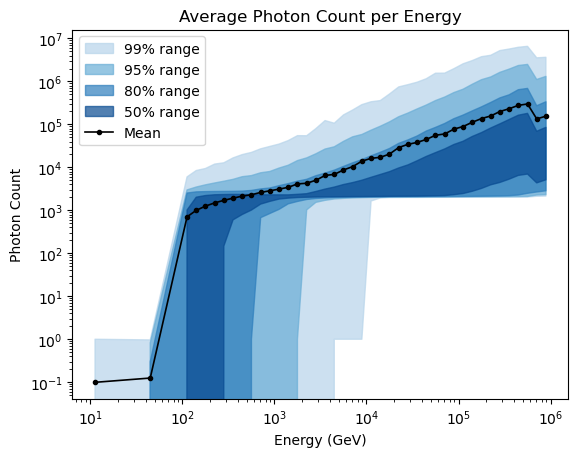

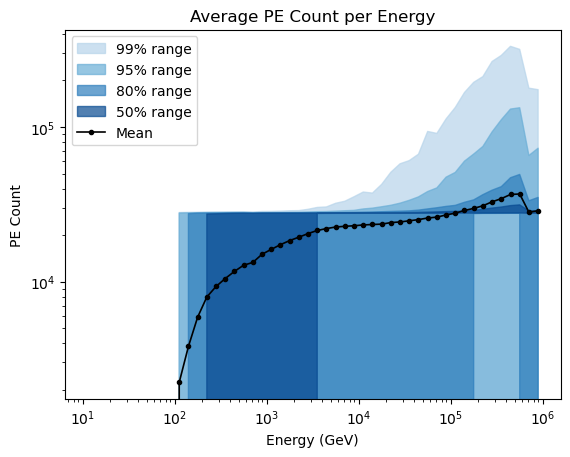

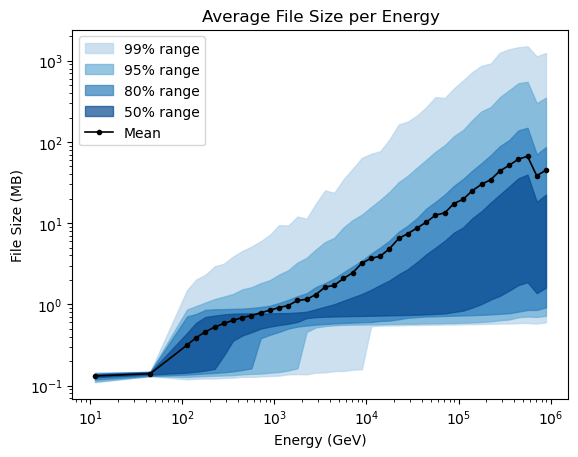

12.876581775783004 TB 4310.455671212598 photon per MB


In [ ]:
#Extract data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import sys
import math

# ── Configuration ─────────────────────────────────────────────────────────────
PE_THRESHOLD = 20
N_BOOTSTRAP = 1000
CI_LEVEL = 0.99
E_MIN_GEV = 1e1
E_MAX_GEV = 1e6
SEEDS = [1,2,3]
PID = 13
RADIUS = 5
BASE_DIR = "/scratch/general/vast/u1520754/muon_sim_chain_tree"


# ── Helper functions ─────────────────────────────────────────────────────────
def load_scan(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    n_missing = (df["file_found"] == 0).sum()
    if n_missing > 0:
        print(f"  WARNING: {n_missing} rows had file_found=0 and will be dropped.")
        index = (df["file_found"] == 0)
        """print("zenith",set(df["zen"][index]))
        print("azimuth",set(df["az"][index]))
        print("height",set(df["height"][index]))"""
    df = df[df["file_found"] == 1].copy()
    df["r"] = np.sqrt(df["tel_x"]**2 + df["tel_z"]**2).round(4)
    df["detected"] = (df["max_pe"] >= PE_THRESHOLD).astype(float)
    return df

def slant_depth(zem, obs_height, zenith_rad):
    theta = np.pi - zenith_rad
    arg = (obs_height / zem) * np.sin(theta)
    arg = np.clip(arg, -1.0, 1.0)
    beta = np.where(np.isfinite(arg), np.arcsin(arg), 0.0)
    beta = np.clip(beta, 0.0, np.pi/2)
    #beta = np.clip(np.arcsin((obs_height / zem) * np.sin(theta)), 0, np.pi/2)
    alpha = np.pi - theta - beta
    s = zem * np.sin(alpha) / np.sin(theta)
    return np.clip(s, 0, np.inf)
def incidence_angle(Zenith_deg, Azimuth_deg):
    Zenith = Zenith_deg
    Azimuth = Azimuth_deg
    cos_Zenith = np.cos(np.radians(Zenith))
    cos_Azimuth = np.cos(np.radians(Azimuth - 180))
    cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
    Incidence = np.degrees(np.arccos(cos_Incidence))
    return Incidence
def bootstrap_trigger_rate(max_pe_in_bin, threshold, n_boot=N_BOOTSTRAP):
    alpha_ci = 1.0 - CI_LEVEL
    lo_pct = 100 * alpha_ci / 2
    hi_pct = 100 * (1 - alpha_ci / 2)
    n = len(max_pe_in_bin)
    if n == 0:
        return np.nan, np.nan, np.nan
    observed_rate = np.sum(max_pe_in_bin >= threshold) / n
    boot_rates = np.empty(n_boot)
    for b in range(n_boot):
        sample = np.random.choice(max_pe_in_bin, size=n, replace=True)
        boot_rates[b] = np.sum(sample >= threshold) / n
    ci_low = np.percentile(boot_rates, lo_pct)
    ci_high = np.percentile(boot_rates, hi_pct)
    return observed_rate, ci_low, ci_high

import re
import os

def get_available_energies(base_dir, pid, radius, e_min_GeV, e_max_GeV):
    """
    Scan BASE_DIR for folders matching the given PID and RADIUS,
    extract energy values, and filter by [e_min_GeV, e_max_GeV].
    Returns sorted list of (energy_GeV, energy_str) tuples.
    """
    pattern = re.compile(
        rf"Muon_pid{pid}_E([0-9]+\.?[0-9]*e[+-]?[0-9]+)_R{radius}$"
    )
    found = {}
    for name in os.listdir(base_dir):
        m = pattern.match(name)
        if m:
            energy_str = m.group(1)
            energy_val = float(energy_str)
            if e_min_GeV <= energy_val <= e_max_GeV:
                found[energy_val] = energy_str

    return sorted(found.items())  # sorted by energy_GeV


available = get_available_energies(BASE_DIR, PID, RADIUS, E_MIN_GEV, E_MAX_GEV)
print(f"Found {len(available)} energy files between {E_MIN_GEV:.0e} and {E_MAX_GEV:.0e} GeV:")
for e_val, e_str in available:
    print(f"  E={e_str} ({e_val:.3e} GeV)")

# ── Load only those files ────────────────────────────────────────────────────
dfs = []
missing_energies = []
for energy_val, energy_str in available:
    for seed in SEEDS:
        csv_path = (f"{BASE_DIR}/Muon_pid{PID}_E{energy_str}_R{RADIUS}/"
                    f"csv_output/scan_care_pid{PID}_E{energy_str}_R{RADIUS}_y0_s{seed}.csv")
        try:
            df_tmp = load_scan(csv_path)
            df_tmp["seed"] = seed
            df_tmp["energy_string"] = energy_str
            df_tmp["energy_GeV"] = energy_val
            dfs.append(df_tmp)
            print(f"  Loaded E={energy_str} seed={seed}: {len(df_tmp)} rows")
        except Exception as e:
            missing_energies.append(energy_str)
            print(f"  ⚠ E={energy_str} seed={seed}: {e}")


df = pd.concat(dfs, ignore_index=True)
print(f"\nMerged: {len(df)} total rows from {len(dfs)} file(s)")
print(f"Energy range: {df['energy_GeV'].min():.1f} – {df['energy_GeV'].max():.1f} GeV")
if missing_energies:
    print(f"Missing energies: {sorted(set(missing_energies))}")

# ── Derived columns ──────────────────────────────────────────────────────────
R = np.array(df["r"])
X = np.array(df["tel_x"])
Z = np.array(df["tel_z"])
H = np.array(df["height"])
Zenith = np.array(df["zen"])
Azimuth = np.array(df["az"])
Max_PE = np.array(df["max_pe"])
Time_at_Max_PE = np.array(df["time_at_max_pe_ns"])
Avg_PE = np.array(df["avg_pe"])
Total_PE = np.array(df["total_pe"])
Energy_GeV = np.array(df["energy_GeV"])
Slant = slant_depth(H + 6371e3, 2944 + 6371e3, np.radians(Zenith))/1000 #km
cos_Zenith = np.cos(np.radians(Zenith))
cos_Azimuth = np.cos(np.radians(Azimuth - 180))
cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
Incidence = incidence_angle(Zenith, Azimuth)
#pulse_width = np.array(df["pulse_width_ns"])
#rise_time = np.array(df["rise_time_ns"])
#x_mag = np.array(df["correction_x_m"])
#y_mag = np.array(df["correction_y_m"])
file_size = np.array(df["file_size_MB"])
photon_count = np.array(df["cph_photon_count"])
#max_photon_10ns = np.array(df["cph_max_photons_10ns"])
E_list = np.sort(np.array(list(set(Energy_GeV))))
deleted_low_pe = np.array(df["deleted_low_pe"])

File = []
Photon = []
PE = []

File_low, File_high = [], []
Photon_low, Photon_high = [], []
PE_low, PE_high = [], []

Total_FIle_Size = np.nansum(file_size)/1000 #MB to GB

# --- Coverage levels for nested bands ---
coverages = [50, 80, 95, 99]    # percent
cmap = plt.cm.Blues

# Storage for multi-coverage bands: dict[coverage] -> (lows, highs)
file_bands   = {c: ([], []) for c in coverages}
photon_bands = {c: ([], []) for c in coverages}
pe_bands     = {c: ([], []) for c in coverages}

for energy in E_list:
    mask = Energy_GeV == energy

    f  = np.nanmean(file_size[mask])
    p  = np.nanmean(photon_count[mask])
    pe = np.nanmean(Total_PE[mask])
    File.append(f)
    Photon.append(p)
    PE.append(pe)

    # 99% range (legacy)
    File_low.append(np.nanpercentile(file_size[mask], 0.5))
    File_high.append(np.nanpercentile(file_size[mask], 99.5))
    Photon_low.append(np.nanpercentile(photon_count[mask], 0.5))
    Photon_high.append(np.nanpercentile(photon_count[mask], 99.5))
    PE_low.append(np.nanpercentile(Total_PE[mask], 0.5))
    PE_high.append(np.nanpercentile(Total_PE[mask], 99.5))

    # Multi-coverage percentile bands
    for cov in coverages:
        lo_p = (100 - cov) / 2
        hi_p = 100 - lo_p
        file_bands[cov][0].append(np.nanpercentile(file_size[mask], lo_p))
        file_bands[cov][1].append(np.nanpercentile(file_size[mask], hi_p))
        photon_bands[cov][0].append(np.nanpercentile(photon_count[mask], lo_p))
        photon_bands[cov][1].append(np.nanpercentile(photon_count[mask], hi_p))
        pe_bands[cov][0].append(np.nanpercentile(Total_PE[mask], lo_p))
        pe_bands[cov][1].append(np.nanpercentile(Total_PE[mask], hi_p))

File   = np.array(File)
Photon = np.array(Photon)
PE     = np.array(PE)

File_low, File_high     = np.array(File_low),   np.array(File_high)
Photon_low, Photon_high = np.array(Photon_low), np.array(Photon_high)
PE_low, PE_high         = np.array(PE_low),     np.array(PE_high)

for cov in coverages:
    file_bands[cov]   = (np.array(file_bands[cov][0]),   np.array(file_bands[cov][1]))
    photon_bands[cov] = (np.array(photon_bands[cov][0]), np.array(photon_bands[cov][1]))
    pe_bands[cov]     = (np.array(pe_bands[cov][0]),     np.array(pe_bands[cov][1]))


def plot_with_bands(E_list, mean, bands_dict, coverages, ylabel, title):
    fig, ax = plt.subplots()
    # Widest first (lightest), narrowest last (darkest)
    order = sorted(coverages, reverse=True)
    n = len(order)
    for i, cov in enumerate(order):
        lo, hi = bands_dict[cov]
        color = cmap(0.3 + 0.6 * (i / max(1, n - 1)))
        ax.fill_between(E_list, lo, hi, color=color, alpha=0.7,
                        label=f'{cov}% range')
    ax.plot(E_list, mean, 'k.-', lw=1.2, label='Mean')
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.show()


# --- Photon Count Plot ---
plot_with_bands(E_list, Photon, photon_bands, coverages,
                "Photon Count", "Average Photon Count per Energy")

# --- PE Count Plot ---
plot_with_bands(E_list, PE, pe_bands, coverages,
                "PE Count", "Average PE Count per Energy")

plot_with_bands(E_list, File, file_bands, coverages,
                "File Size (MB)", "Average File Size per Energy")

print(Total_FIle_Size/1000, "TB", np.nanmean(Photon)/np.nanmean(File), "photon per MB")


In [ ]:
file_size[deleted_low_pe==0]

array([], dtype=float64)

In [ ]:
np.sum(file_size[deleted_low_pe==1])/1000

np.float64(1.034383566)

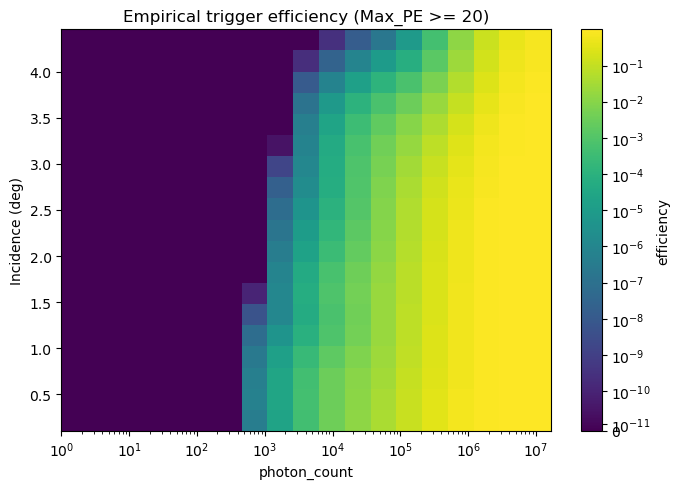

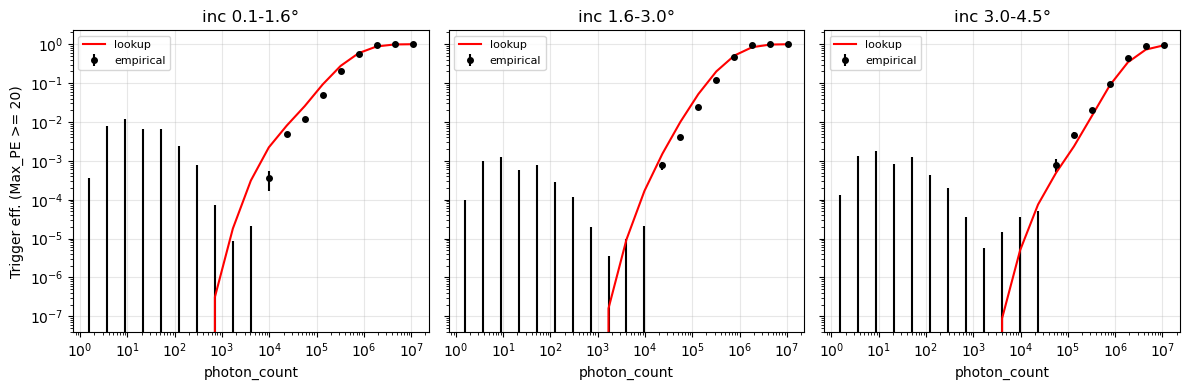

In [2]:
# Empirical trigger efficiency: P(Max_PE >= threshold | photon_count, incidence)
# =============================================================================
from scipy.ndimage import gaussian_filter
from matplotlib.colors import SymLogNorm

# ---------- 1. Clean inputs ----------
m = (np.isfinite(photon_count) & (photon_count > 0)
     & np.isfinite(Max_PE)     & (Max_PE >= 0)
     & np.isfinite(Incidence))
pc_  = photon_count[m]
pe_  = Max_PE[m]
inc_ = Incidence[m]
hit_ = (pe_ >= PE_THRESHOLD).astype(float)

# ---------- 2. Define 2-D bins ----------
pc_edges  = np.logspace(np.log10(pc_.min()), np.log10(pc_.max()), 20)
inc_edges = np.linspace(inc_.min(),inc_.max(), 20)
pc_cen    = np.sqrt(pc_edges[:-1] * pc_edges[1:])
inc_cen   = 0.5*(inc_edges[:-1] + inc_edges[1:])

# ---------- 3. Build empirical efficiency table ----------
N_tot, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges])
N_hit, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges], weights=hit_)

with np.errstate(invalid='ignore', divide='ignore'):
    eff = np.where(N_tot >= 5, N_hit / N_tot, np.nan)
    eff_err = np.where(N_tot >= 5, np.sqrt(eff*(1-eff)/N_tot), np.nan)

# Light smoothing to fill noisy bins (optional)
eff_smooth = eff.copy()
mask = np.isfinite(eff_smooth)
eff_smooth[~mask] = 0
weights = mask.astype(float)
eff_smooth = gaussian_filter(eff_smooth, sigma=0.8) / np.clip(
    gaussian_filter(weights, sigma=0.8), 1e-6, None)

# ---------- 4. Lookup function with bilinear interpolation ----------
from scipy.interpolate import RegularGridInterpolator
interp = RegularGridInterpolator(
    (np.log10(pc_cen), inc_cen), eff_smooth,
    bounds_error=False, fill_value=None, method='linear')

def trigger_eff(N_gamma, inc_deg):
    N_gamma = np.asarray(N_gamma, dtype=float)
    inc_deg = np.asarray(inc_deg, dtype=float)
    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)
    pts = np.column_stack([
        np.log10(np.clip(N_b.ravel(), pc_.min(), pc_.max())),
        np.clip(inc_b.ravel(), inc_.min(), inc_.max()),
    ])
    vals = np.clip(interp(pts), 0.0, 1.0)
    return vals.reshape(N_b.shape)

# ---------- 5. Plot the efficiency map ----------
fig, ax = plt.subplots(figsize=(7,5))
pcm = ax.pcolormesh(pc_edges, inc_edges, eff_smooth.T,
                    cmap='viridis', shading='auto', norm=SymLogNorm(linthresh=np.min(eff_smooth[np.where(eff_smooth>0)]), linscale=0.5, base=10))
ax.set_xscale('log')
ax.set_xlabel("photon_count"); ax.set_ylabel("Incidence (deg)")
ax.set_title(f"Empirical trigger efficiency (Max_PE >= {PE_THRESHOLD})")
plt.colorbar(pcm, ax=ax, label='efficiency')
plt.tight_layout(); plt.show()

# ---------- 6. Slice validation ----------
bounds = np.linspace(inc_.min(), inc_.max(), 4)
slices = list(zip(bounds[:-1], bounds[1:]))
fig, axes = plt.subplots(1, len(slices), figsize=(4*len(slices), 4), sharey=True)
for ax, (ilo, ihi) in zip(axes, slices):
    sel = (inc_ >= ilo) & (inc_ < ihi)
    emp, err = [], []
    for i in range(len(pc_cen)):
        s2 = sel & (pc_ >= pc_edges[i]) & (pc_ < pc_edges[i+1])
        n = s2.sum()
        if n >= 5:
            p = np.mean(hit_[s2]); emp.append(p)
            err.append(np.sqrt(p*(1-p)/n) + 1.0/n)
        else:
            emp.append(np.nan); err.append(np.nan)
    emp, err = np.array(emp), np.array(err)
    pred = trigger_eff(pc_cen, 0.5*(ilo+ihi))
    ax.errorbar(pc_cen, emp, yerr=err, fmt='ko', ms=4, label='empirical')
    ax.plot(pc_cen, pred, 'r-', label='lookup')
    ax.set_xscale('log')#; ax.set_ylim(-0.05, 1.1)
    ax.set_yscale('log')
    ax.set_xlabel("photon_count")
    ax.set_title(f"inc {ilo:.1f}-{ihi:.1f}°")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
plt.tight_layout(); plt.show()


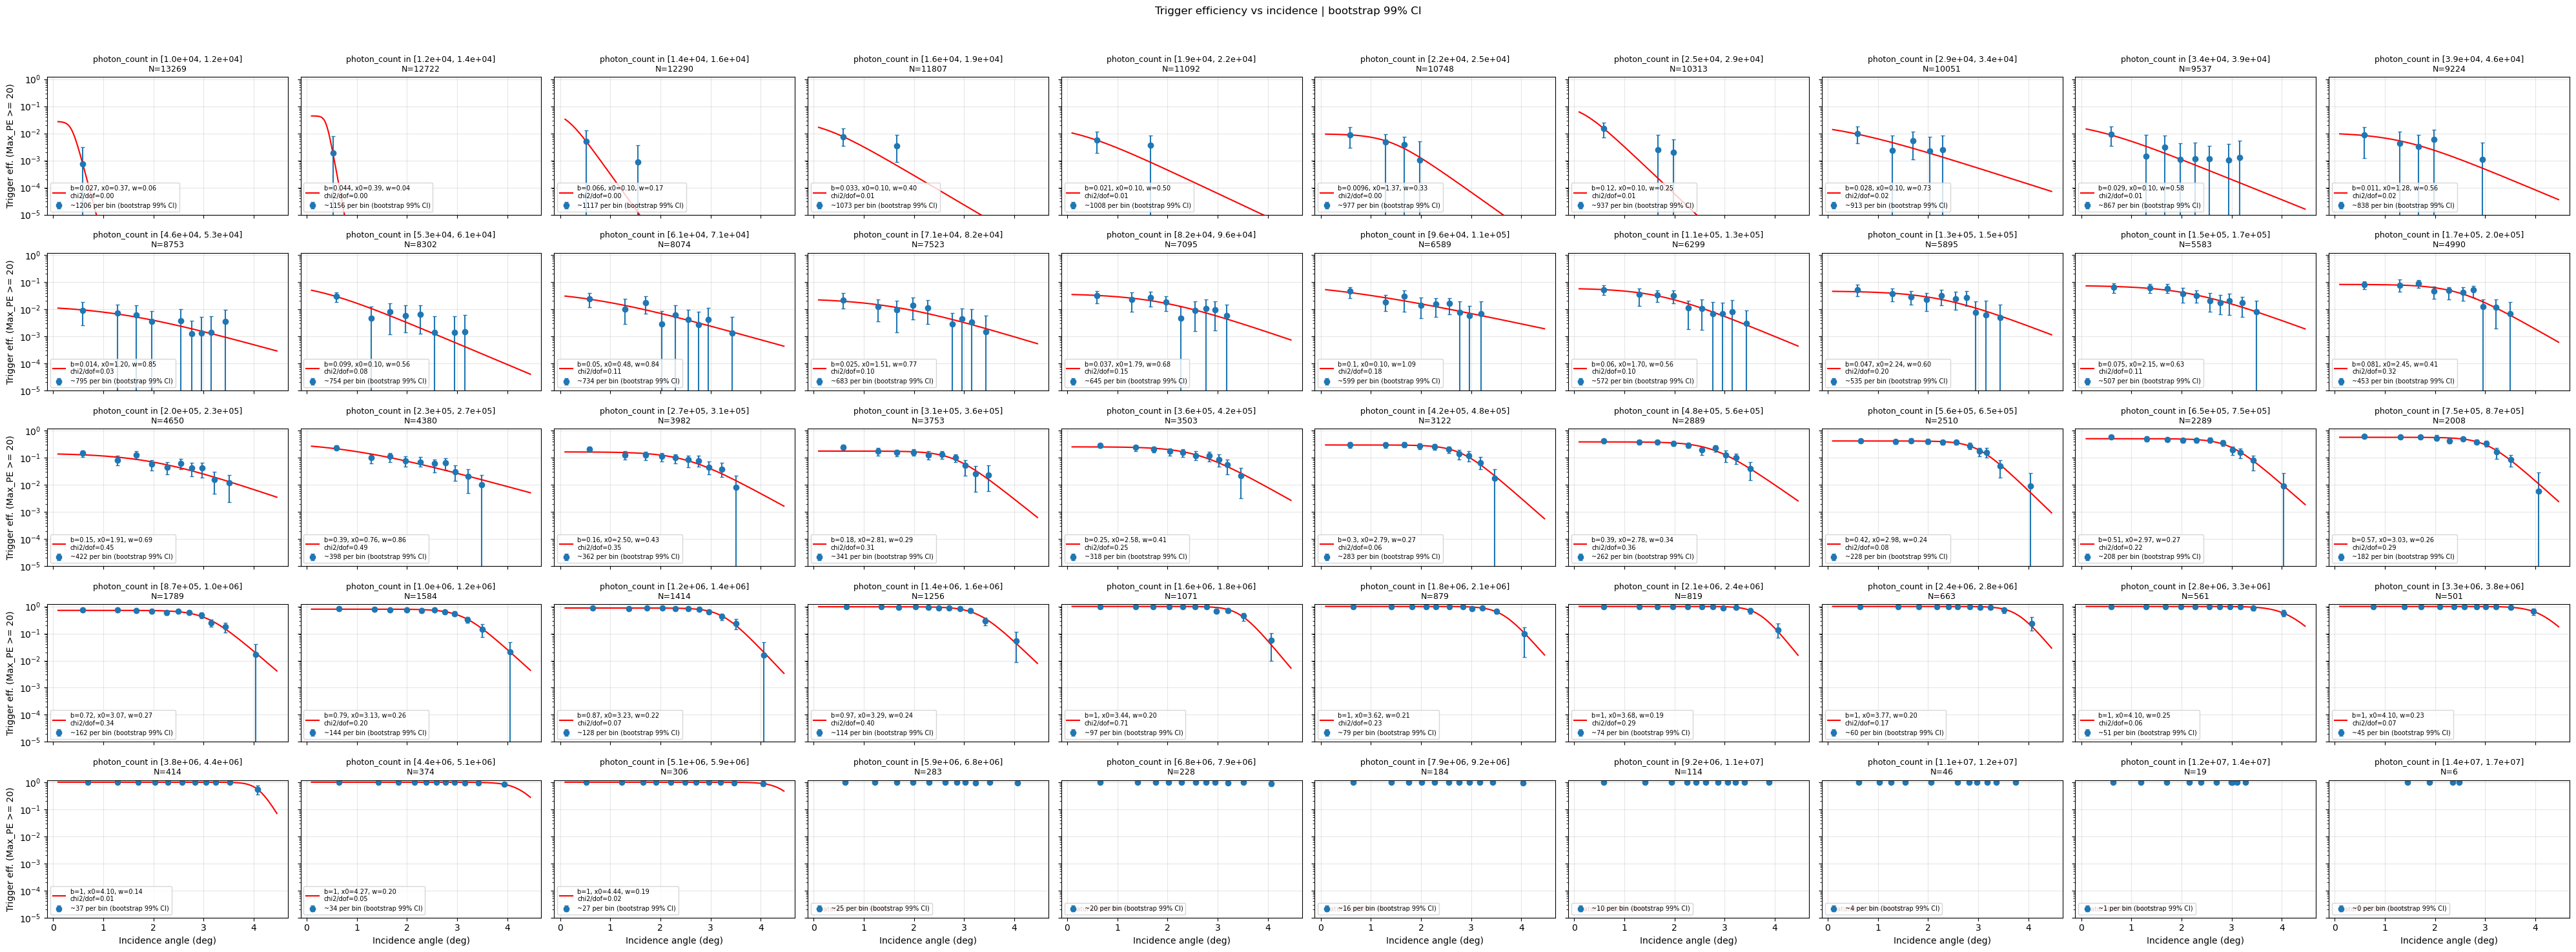

Skipped saturated bins (eff ~ 1 across incidence):
  pc_mean=5.502e+06, N=306
  pc_mean=6.375e+06, N=283
  pc_mean=7.387e+06, N=228
  pc_mean=8.559e+06, N=184
  pc_mean=9.917e+06, N=114
  pc_mean=1.149e+07, N=46
  pc_mean=1.331e+07, N=19
  pc_mean=1.543e+07, N=6
PER-BIN LOGISTIC CUTOFF FIT DIAGNOSTICS
Fit equation: eff(x) = b / (1 + exp((x - x0) / w))
Error bars:   bootstrap 99% CI (N_boot=200)
--------------------------------------------------------------------------------
     pc_mean          b         ±b         x0        ±x0          w         ±w   chi2/dof     minN
--------------------------------------------------------------------------------
   1.132e+04     0.0274    1.1e+09      0.369    2.5e+09      0.063    6.2e+06       0.00     1220
   1.312e+04     0.0428    8.9e+11      0.384      1e+12      0.046    2.9e+09       0.00     1044
   1.520e+04     0.0708    3.5e+03      0.100      9e+03      0.164    1.4e+02       0.00     1012
   1.761e+04     0.0347        5.1      0.10

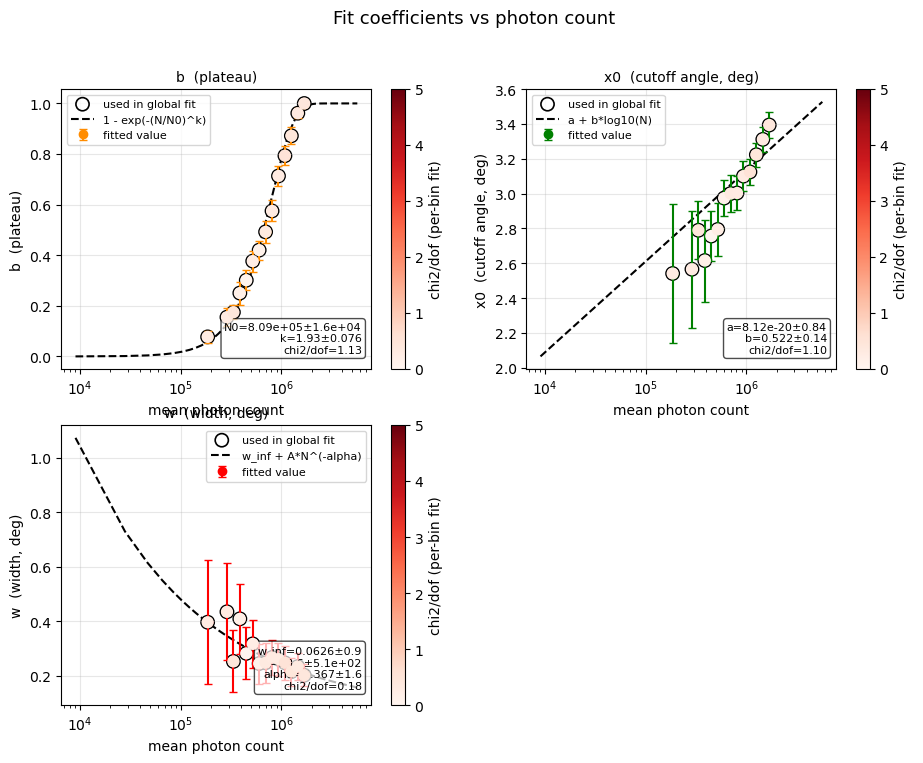


PHYSICAL MODEL FITS (coefficient vs photon count N)

--- Model for parameter 'x0' ---
Equation:  x0(N) = a + b * log10(N)
             a = 8.122e-20 ± 0.84
             b = 0.5221 ± 0.14
      chi2/dof = 1.101

--- Model for parameter 'b' ---
Equation:  b(N)  = 1 - exp(-(N/N0)^k)
            N0 = 8.094e+05 ± 1.6e+04
             k = 1.929 ± 0.076
      chi2/dof = 1.127

--- Model for parameter 'w' ---
Equation:  w(N)  = w_inf + A * N**(-alpha)
         w_inf = 0.06261 ± 0.9
             A = 28.59 ± 5.1e+02
         alpha = 0.3668 ± 1.6
      chi2/dof = 0.180


In [3]:
#Fitting Model
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize

# --- User settings ---
PE_THRESHOLD = 20
n_photon_bins = 50
n_inc_bins = 10
ncols = 10
BIAS_QUANTILE = 0.1 #bias toward high incidence value
MIN_EVENTS_PER_INC_BIN = 2
MAX_CHI2_DOF = 5.0
MAX_X0_ERR_DEG = 0.5
MAX_W_ERR_DEG = 0.5
EFF_ERR_FLOOR = 0.01
B_ERR_FLOOR = 0.0001
W_ERR_FLOOR = 0.01
MIN_PARAM_ERR = 1e-4
SATURATION_EFF = 0.9
B_MIN_SIGNIFICANCE = 0.09
W_MIN_BOUND = 1e-3
B_SATURATION_MAX = 1
X0_MODEL = "log"  # options: "softplus", "log"

N_BOOTSTRAP = 200
CI_LEVEL = 99.0  # percent
CI_ALPHA = (100.0 - CI_LEVEL) / 2.0  # 0.5 for 99%

# ---- bootstrap helper ----
def bootstrap_eff_ci(trig_bin, n_boot=N_BOOTSTRAP, ci_alpha=CI_ALPHA):
    """
    trig_bin: 1D array of 0/1 for events in one incidence bin.
    Returns (eff, err_lo, err_hi) where err_lo/hi are half-CI widths
    suitable for asymmetric errorbar.
    """
    n = len(trig_bin)
    if n == 0:
        return np.nan, np.nan, np.nan
    eff = trig_bin.mean()
    boot_effs = np.array([
        np.random.choice(trig_bin, size=n, replace=True).mean()
        for _ in range(n_boot)
    ])
    lo = np.percentile(boot_effs, ci_alpha)
    hi = np.percentile(boot_effs, 100.0 - ci_alpha)
    # symmetric error for fitting: use half-width of CI
    err = (hi - lo) / 2.0
    err = max(err, EFF_ERR_FLOOR)
    return eff, lo, hi, err

# ---- preprocess ----
mask = (
    np.isfinite(photon_count) & (photon_count > 0) &
    np.isfinite(Max_PE) & (Max_PE > 0) &
    np.isfinite(Incidence)
)

pc = photon_count[mask]
inc = Incidence[mask]
pe = Max_PE[mask]
trig = (pe >= PE_THRESHOLD).astype(float)

pc_for_edges = pc[pe >= PE_THRESHOLD]
pc_edges = np.logspace(min(np.log10(pc_for_edges)), max(np.log10(pc_for_edges)),n_photon_bins + 1)#np.unique(np.quantile(pc_for_edges, np.linspace(0, 1, n_photon_bins + 1)))
n_photon_bins = len(pc_edges) - 1

def logistic_cutoff(x, b, x0, w):
    exponent = np.clip((x - x0) / w, -500, 500)
    return b / (1.0 + np.exp(exponent))


# ---- helper: compute bootstrap eff/err arrays for a slice ----
def compute_bootstrap_arrays(inc_slice, trig_slice, inc_edges):
    """
    For each incidence bin defined by inc_edges, bootstrap the efficiency.
    Returns: eff, err_sym, err_lo, err_hi, total arrays (one per bin).
    """
    n_bins = len(inc_edges) - 1
    eff_arr    = np.full(n_bins, np.nan)
    err_arr    = np.full(n_bins, np.nan)
    err_lo_arr = np.full(n_bins, np.nan)
    err_hi_arr = np.full(n_bins, np.nan)
    total_arr  = np.zeros(n_bins, dtype=int)

    for k in range(n_bins):
        in_bin = (inc_slice >= inc_edges[k]) & (inc_slice < inc_edges[k + 1])
        trig_bin = trig_slice[in_bin]
        total_arr[k] = len(trig_bin)
        if len(trig_bin) == 0:
            continue
        eff, lo, hi, err = bootstrap_eff_ci(trig_bin)
        eff_arr[k]    = eff
        err_lo_arr[k] = eff - lo   # distance below
        err_hi_arr[k] = hi - eff   # distance above
        err_arr[k]    = err

    return eff_arr, err_arr, err_lo_arr, err_hi_arr, total_arr

# ======================================================================
# PLOT: trigger efficiency per photon-count bin
# ======================================================================
nrows = int(np.ceil(n_photon_bins / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, sharey=True
)
axes = np.atleast_1d(axes).ravel()
x_fit = np.linspace(inc.min(), inc.max(), 200)

for i in range(n_photon_bins):
    ax = axes[i]
    pc_lo, pc_hi = pc_edges[i], pc_edges[i + 1]
    sub = (pc >= pc_lo) & (pc < pc_hi)
    n_sub = sub.sum()

    if n_sub == 0:
        ax.set_title(f"[{pc_lo:.1e},{pc_hi:.1e}]\nN=0")
        continue

    inc_sub = inc[sub]
    trig_sub = trig[sub]

    inc_threshold = np.quantile(inc_sub, BIAS_QUANTILE)
    inc_upper = inc_sub[inc_sub >= inc_threshold]
    if len(inc_upper) >= n_inc_bins:
        inc_edges_upper = np.unique(
            np.quantile(inc_upper, np.linspace(0, 1, n_inc_bins + 1))
        )
        inc_edges = np.unique(np.concatenate([[inc_sub.min()], inc_edges_upper]))
    else:
        inc_edges = np.unique(
            np.quantile(inc_sub, np.linspace(0, 1, n_inc_bins + 1))
        )

    if len(inc_edges) < 3:
        ax.set_title(f"[{pc_lo:.1e},{pc_hi:.1e}]\nN={n_sub}")
        ax.text(0.5, 0.5, "insufficient bins", transform=ax.transAxes,
                ha='center', va='center', fontsize=8, color='red')
        continue

    n_bins_actual = len(inc_edges) - 1
    inc_centers = 0.5 * (inc_edges[:-1] + inc_edges[1:])

    eff, err, err_lo, err_hi, total = compute_bootstrap_arrays(
        inc_sub, trig_sub, inc_edges
    )

    # asymmetric error bars from bootstrap CI
    yerr_asym = np.array([
        np.where(np.isfinite(err_lo), err_lo, 0),
        np.where(np.isfinite(err_hi), err_hi, 0)
    ])

    ax.errorbar(inc_centers, eff, yerr=yerr_asym, fmt='o', capsize=2,
                label=f"~{n_sub // n_bins_actual} per bin (bootstrap {CI_LEVEL:.0f}% CI)")

    eff_valid = eff[np.isfinite(eff)]
    saturated = bool(eff_valid.size > 0 and np.all(eff_valid >= SATURATION_EFF))

    good = np.isfinite(eff) & (total > 0)
    min_total = int(np.min(total[total > 0])) if np.any(total > 0) else 0

    if saturated:
        ax.text(0.05, 0.05, f"saturated (eff>={SATURATION_EFF:.2f})",
                transform=ax.transAxes, fontsize=7, color='darkred')
    elif good.sum() >= 4 and min_total >= MIN_EVENTS_PER_INC_BIN:
        xd = inc_centers[good]
        yd = eff[good]
        sd = np.where(err[good] > 0, err[good], EFF_ERR_FLOOR)

        inc_range = inc_edges[-1] - inc_edges[0]
        b0 = min(max(np.nanmax(yd), 0.05), 1.0)
        x0_0 = xd[np.argmin(np.abs(yd - 0.5 * np.nanmax(yd)))]
        w0 = max(0.02 * (inc_range + 1e-6), 1e-3)
        p0 = [b0, x0_0, w0]
        bounds = (
            [0.0, inc_edges[0], 1e-3],
            [1.05, inc_edges[-1], 0.4 * inc_range],
        )

        try:
            popt, _ = curve_fit(
                logistic_cutoff, xd, yd, p0=p0, sigma=sd,
                absolute_sigma=True, bounds=bounds, maxfev=20000
            )
            y_model = logistic_cutoff(xd, *popt)
            chi2 = np.sum(((yd - y_model) / sd) ** 2)
            dof = len(xd) - 3
            chi2_dof = chi2 / dof if dof > 0 else np.nan

            ax.plot(x_fit, logistic_cutoff(x_fit, *popt), 'r-', lw=1.5,
                    label=(f"b={popt[0]:.2g}, x0={popt[1]:.2f}, "
                           f"w={popt[2]:.2f}\nchi2/dof={chi2_dof:.2f}"))
        except Exception:
            ax.text(0.05, 0.05, "fit failed", transform=ax.transAxes,
                    fontsize=8, color='red')
    else:
        ax.text(0.05, 0.05, f"low stats (min N={min_total})",
                transform=ax.transAxes, fontsize=7, color='darkred')

    ax.legend(fontsize=7, loc='lower left')
    ax.set_ylim(1e-5, 1.2)
    ax.set_yscale("log")
    ax.set_title(f"photon_count in [{pc_lo:.1e}, {pc_hi:.1e}]\nN={n_sub}", fontsize=9)
    ax.grid(alpha=0.3)

for j in range(n_photon_bins, len(axes)):
    axes[j].set_visible(False)

for ax in axes[:n_photon_bins]:
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel("Incidence angle (deg)")
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")

fig.suptitle(f"Trigger efficiency vs incidence | bootstrap {CI_LEVEL:.0f}% CI", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ======================================================================
# PER-BIN FIT LOOP
# ======================================================================
pc_means, x0_vals, x0_errs = [], [], []
b_vals, b_errs = [], []
w_vals, w_errs = [], []
chi2_vals = []
min_counts = []
mean_counts = []
saturated_bins = []
saturated_ranges = []

for i in range(n_photon_bins):
    pc_lo, pc_hi = pc_edges[i], pc_edges[i + 1]
    sub = (pc >= pc_lo) & (pc < pc_hi)
    if sub.sum() == 0:
        continue

    inc_sub = inc[sub]
    trig_sub = trig[sub]

    inc_edges = np.unique(
        np.quantile(inc_sub, np.linspace(0, 1, n_inc_bins + 1))
    )
    if len(inc_edges) < 3:
        continue

    inc_centers = 0.5 * (inc_edges[:-1] + inc_edges[1:])
    inc_range = inc_edges[-1] - inc_edges[0]

    eff, err, err_lo, err_hi, total = compute_bootstrap_arrays(
        inc_sub, trig_sub, inc_edges
    )

    eff_valid = eff[np.isfinite(eff)]
    if eff_valid.size > 0 and np.all(eff_valid >= SATURATION_EFF):
        saturated_bins.append((0.5 * (pc_lo + pc_hi), int(sub.sum())))
        saturated_ranges.append((pc_lo, pc_hi))
        continue

    good = np.isfinite(eff) & (total > 0)
    if good.sum() < 4:
        continue

    xd = inc_centers[good]
    yd = eff[good]
    sd = np.where(err[good] > 0, err[good], EFF_ERR_FLOOR)

    min_total = int(np.min(total[total > 0])) if np.any(total > 0) else 0
    mean_total = float(np.mean(total[total > 0])) if np.any(total > 0) else 0.0

    b0 = min(max(np.nanmax(yd), 0.05), 1.0)
    x0_0 = xd[np.argmin(np.abs(yd - 0.5 * np.nanmax(yd)))]
    w0 = max(0.02 * (inc_range + 1e-6), 1e-3)
    p0 = [b0, x0_0, w0]
    bounds = (
        [0.0, inc_edges[0], 1e-3],
        [1.05, inc_edges[-1], 0.4 * inc_range],
    )

    try:
        popt, pcov = curve_fit(
            logistic_cutoff, xd, yd, p0=p0, sigma=sd,
            absolute_sigma=True, bounds=bounds, maxfev=20000
        )
        perr = np.sqrt(np.diag(pcov))
        y_model = logistic_cutoff(xd, *popt)
        chi2 = np.sum(((yd - y_model) / sd) ** 2)
        dof = len(xd) - 3
        chi2_dof = chi2 / dof if dof > 0 else np.nan

        pc_means.append(0.5 * (pc_lo + pc_hi))
        b_vals.append(popt[0]);  b_errs.append(perr[0])
        x0_vals.append(popt[1]); x0_errs.append(perr[1])
        w_vals.append(popt[2]);  w_errs.append(perr[2])
        chi2_vals.append(chi2_dof)
        min_counts.append(min_total)
        mean_counts.append(mean_total)

    except Exception:
        continue

if saturated_bins:
    print("Skipped saturated bins (eff ~ 1 across incidence):")
    for pc_mean, n_sub in saturated_bins:
        print(f"  pc_mean={pc_mean:.3e}, N={n_sub}")

pc_means   = np.array(pc_means)
b_vals,  b_errs  = np.array(b_vals),  np.array(b_errs)
x0_vals, x0_errs = np.array(x0_vals), np.array(x0_errs)
w_vals,  w_errs  = np.array(w_vals),  np.array(w_errs)
chi2_vals  = np.array(chi2_vals)
min_counts = np.array(min_counts)
mean_counts = np.array(mean_counts)

# -- quality mask --
cutoff_in_range = (
    (x0_vals + 2.0 * w_vals <= inc.max()) &
    (x0_vals - 2.0 * w_vals >= inc.min())
)
finite_mask = (
    np.isfinite(chi2_vals) & np.isfinite(x0_errs) &
    np.isfinite(w_errs) & np.isfinite(b_errs)
)
stats_mask = min_counts >= MIN_EVENTS_PER_INC_BIN
err_mask = (
    (x0_errs < MAX_X0_ERR_DEG) & (w_errs < MAX_W_ERR_DEG) &
    (b_errs > MIN_PARAM_ERR) & (x0_errs > MIN_PARAM_ERR) & (w_errs > MIN_PARAM_ERR)
)
chi2_mask = chi2_vals < MAX_CHI2_DOF

with np.errstate(divide='ignore', invalid='ignore'):
    b_signif = np.where(b_errs > 0, b_vals / b_errs, 0.0)
b_signif_mask = b_signif >= B_MIN_SIGNIFICANCE

w_bound_mask = w_vals > W_MIN_BOUND * 1.05
b_saturation_mask = b_vals < B_SATURATION_MAX

quality_mask = (
    finite_mask & stats_mask & err_mask &
    chi2_mask & cutoff_in_range & b_signif_mask &
    w_bound_mask & b_saturation_mask
)

# -- diagnostics print --
print("=" * 80)
print("PER-BIN LOGISTIC CUTOFF FIT DIAGNOSTICS")
print("=" * 80)
print("Fit equation: eff(x) = b / (1 + exp((x - x0) / w))")
print(f"Error bars:   bootstrap {CI_LEVEL:.0f}% CI (N_boot={N_BOOTSTRAP})")
print("-" * 80)
print(f"{'pc_mean':>12} {'b':>10} {'±b':>10} {'x0':>10} {'±x0':>10} "
      f"{'w':>10} {'±w':>10} {'chi2/dof':>10} {'minN':>8}")
print("-" * 80)
for i in range(len(pc_means)):
    print(f"{pc_means[i]:12.3e} "
          f"{b_vals[i]:10.3g} {b_errs[i]:10.2g} "
          f"{x0_vals[i]:10.3f} {x0_errs[i]:10.2g} "
          f"{w_vals[i]:10.3f} {w_errs[i]:10.2g} "
          f"{chi2_vals[i]:10.2f} {min_counts[i]:8d}")
print("-" * 80)
print(f"Bins fitted: {len(pc_means)} | Bins used for global fits: {int(np.sum(quality_mask))}")
print("=" * 80)

dropped = ~quality_mask
if np.any(dropped):
    print("\nBins EXCLUDED from global fits:")
    print(f"{'pc_mean':>12} {'b/σ_b':>8} {'chi2/dof':>10} {'minN':>8}  reasons")
    for i in np.where(dropped)[0]:
        reasons = []
        if not finite_mask[i]:     reasons.append("nonfinite")
        if not stats_mask[i]:      reasons.append(f"minN<{MIN_EVENTS_PER_INC_BIN}")
        if not err_mask[i]:        reasons.append("err-cut")
        if not chi2_mask[i]:       reasons.append(f"chi2>{MAX_CHI2_DOF}")
        if not cutoff_in_range[i]: reasons.append("x0 out of range")
        if not b_signif_mask[i]:   reasons.append(f"b/σ_b<{B_MIN_SIGNIFICANCE}")
        if not b_saturation_mask[i]: reasons.append(f"b>={B_SATURATION_MAX}")
        if not w_bound_mask[i]:      reasons.append(f"w<={W_MIN_BOUND:g}")
        bs = b_signif[i] if np.isfinite(b_signif[i]) else 0.0
        print(f"{pc_means[i]:12.3e} {bs:8.2f} {chi2_vals[i]:10.2f} "
              f"{min_counts[i]:8d}  " + ", ".join(reasons))

# -- physical models --
def x0_softplus(N, x0_lo, Nt, s, p):
    N = np.maximum(N, 1e-12)
    Nt = np.maximum(Nt, 1e-12)
    return x0_lo + s * np.log1p((N / Nt) ** p)
    
def x0_log(N, a, b_coef):
    return a + b_coef * np.log10(N)

x0_model_cfg = {
    "softplus": {
        "fn": x0_softplus,
        "p0": [3.0, 1e6, 0.5, 2.0],
        "bounds": ([2.0, 1e5, 0.0, 0.5], [5.0, 1e7, 5.0, 10.0]),
        "label": r"x0_lo + s*log1p((N/Nt)^p)",
        "param_names": ["x0_lo", "Nt", "s", "p"],
    },
    "log": {
        "fn": x0_log,
        "p0": [3.0, 0.5],
        "bounds": ([0.0, -5.0], [10.0, 5.0]),
        "label": r"a + b*log10(N)",
        "param_names": ["a", "b"],
    },
}

if X0_MODEL not in x0_model_cfg:
    raise ValueError(f"Unknown X0_MODEL='{X0_MODEL}'. Use 'softplus' or 'log'.")
x0_model = x0_model_cfg[X0_MODEL]
x0_model_fn = x0_model["fn"]

def plateau_model(N, N0, k):
    N = np.maximum(N, 1e-12)
    return 1.0 - np.exp(-(N / N0) ** k)

def w_model(N, w_inf, A, alpha):
    N = np.maximum(N, 1e-12)
    return w_inf + A * N**(-alpha)

results = {}

def fit_model(fn, xdata, ydata, yerr, p0, bounds):
    sigma = np.where(yerr > 0, yerr, EFF_ERR_FLOOR)
    popt, pcov = curve_fit(
        fn, xdata, ydata, p0=p0, sigma=sigma,
        absolute_sigma=True, bounds=bounds, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    residuals = ydata - fn(xdata, *popt)
    chi2 = np.sum((residuals / sigma) ** 2)
    dof = len(xdata) - len(popt)
    chi2_dof = chi2 / dof if dof > 0 else np.nan
    return popt, perr, pcov, chi2_dof

ok_x0 = quality_mask & np.isfinite(x0_errs) #old
#ok_x0 = quality_mask & np.isfinite(x0_errs) & (x0_errs < 0.3)  # was just isfinite

try:
    popt, perr, pcov, c2 = fit_model(
        x0_model_fn, pc_means[ok_x0], x0_vals[ok_x0],
        np.maximum(x0_errs[ok_x0], W_ERR_FLOOR),
        p0=x0_model["p0"],
        bounds=x0_model["bounds"],
    )
    results['x0'] = (popt, perr, pcov, c2)
except Exception as e:
    print(f"x0 model fit failed: {e}")

ok_b = quality_mask & (b_vals < B_SATURATION_MAX) & np.isfinite(b_errs) #old
"""ok_b = (
    quality_mask &
    (b_vals < B_SATURATION_MAX) &
    np.isfinite(b_errs) &
    (b_errs < 0.1) &          # tighter error cut
    (b_vals / b_errs > 3.0)   # stricter significance (was 0.09)
)"""
try:
    popt, perr, pcov, c2 = fit_model(
        plateau_model, pc_means[ok_b], b_vals[ok_b],
        np.maximum(b_errs[ok_b], B_ERR_FLOOR),
        p0=[np.median(pc_means[ok_b]), 1.0],
        bounds=([pc_means.min() * 0.1, 0.1], [pc_means.max() * 10.0, 10.0])
    )
    results['b'] = (popt, perr, pcov, c2)
except Exception as e:
    print(f"b model fit failed: {e}")

ok_w = quality_mask & np.isfinite(w_errs) & (w_vals > 0)
try:
    popt, perr, pcov, c2 = fit_model(
        w_model, pc_means[ok_w], w_vals[ok_w],
        np.maximum(w_errs[ok_w], W_ERR_FLOOR),
        p0=[0.15, 50.0, 0.5],
        bounds=([0.0, 0.0, 0.1], [1.0, 1e5, 1.5])
    )
    results['w'] = (popt, perr, pcov, c2)
except Exception as e:
    print(f"w model fit failed: {e}")

# -- comparison plot --
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
N_smooth = np.linspace(pc_means.min() * 0.8, pc_means.max() * 1.2, 300)

labels      = ['b  (plateau)', 'x0  (cutoff angle, deg)', 'w  (width, deg)']
yvals       = [b_vals, x0_vals, w_vals]
yerrs       = [b_errs, x0_errs, w_errs]
colors      = ['darkorange', 'green', 'red']
model_keys  = ['b', 'x0', 'w']
model_fns   = [plateau_model, x0_model_fn, w_model]
model_labels = {
    'x0': x0_model["label"],
    'b':  r"1 - exp(-(N/N0)^k)",
    'w':  r"w_inf + A*N^(-alpha)",
}
param_names = {
    'x0': x0_model["param_names"],
    'b':  ['N0', 'k'],
    'w':  ['w_inf', 'A', 'alpha'],
}

for ax, lbl, yv, ye, col, mkey, mfn in zip(
        axes[:len(labels)], labels, yvals, yerrs, colors, model_keys, model_fns):

    qm = quality_mask
    ax.errorbar(pc_means[qm], yv[qm], yerr=ye[qm], fmt='o', color=col,
                capsize=3, label='fitted value', zorder=3)
    sc = ax.scatter(pc_means[qm], yv[qm], c=chi2_vals[qm], cmap='Reds',
                    vmin=0, vmax=5, zorder=5, s=60)
    plt.colorbar(sc, ax=ax, label='chi2/dof (per-bin fit)')
    ax.scatter(pc_means[qm], yv[qm],
               facecolors='none', edgecolors='black', s=90,
               linewidths=1.2, label='used in global fit')

    if mkey in results:
        popt, perr, pcov, c2 = results[mkey]
        ax.plot(N_smooth, mfn(N_smooth, *popt), 'k--',
                lw=1.5, label=model_labels[mkey])
        txt = "\n".join(f"{n}={v:.3g}±{e:.2g}"
                        for n, v, e in zip(param_names[mkey], popt, perr))
        txt += f"\nchi2/dof={c2:.2f}"
        ax.text(0.97, 0.05, txt, transform=ax.transAxes, fontsize=8,
                ha='right', va='bottom',
                bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    ax.set_xscale('log')
    ax.set_xlabel('mean photon count')
    ax.set_ylabel(lbl)
    ax.set_title(lbl, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes[len(labels):]:
    ax.axis('off')

fig.suptitle("Fit coefficients vs photon count", fontsize=13)
#fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# -- physical model summary --
print("\n" + "=" * 80)
print("PHYSICAL MODEL FITS (coefficient vs photon count N)")
print("=" * 80)
model_equations = {
    'x0': "x0(N) = x0_lo + s * log1p((N/Nt)^p)" if X0_MODEL == "softplus" else "x0(N) = a + b * log10(N)",
    'b':  "b(N)  = 1 - exp(-(N/N0)^k)",
    'w':  "w(N)  = w_inf + A * N**(-alpha)",
}
for key in ['x0', 'b', 'w']:
    print(f"\n--- Model for parameter '{key}' ---")
    print(f"Equation:  {model_equations[key]}")
    if key in results:
        popt, perr, pcov, c2 = results[key]
        for name, val, err in zip(param_names[key], popt, perr):
            print(f"  {name:>12} = {val:.4g} ± {err:.2g}")
        print(f"  {'chi2/dof':>12} = {c2:.3f}")
    else:
        print("  FIT FAILED or not available")
print("=" * 80)


In [22]:
# Bootstrap with combined statistical + binning systematics - store med/lo/hi only
# =============================================================================
import os
import numpy as np
from joblib import Parallel, delayed
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter, map_coordinates

# ---------- Config ----------
N_BOOT   = 100
CI_LEVEL = 68  # 99.7 ~ 3 sigma, 95 ~ 2 sigma, 68 ~ 1 sigma
N_JOBS   = os.cpu_count()
SEED     = 0
MIN_CNT  = 20

NPC_RANGE    = (10, 50)
NINC_RANGE   = (10, 50)
SMOOTH_RANGE = (0.7, 1)
LOG10_PC_MIN_RANGE = (np.log10(pc_.min()), 3)  # 3.8

# Legacy grid sizes for initial empirical cube (kept for step order)
N_COMMON_PC_DATA  = 100
N_COMMON_INC_DATA = 100

# ---------- Worker ----------
def build_interp_from_edges(pc_s, inc_s, hit_s,
                            pc_edges, inc_edges, smooth, min_cnt=MIN_CNT):
    pc_cen  = np.sqrt(pc_edges[:-1] * pc_edges[1:])
    inc_cen = 0.5 * (inc_edges[:-1] + inc_edges[1:])
    N_tot, _, _ = np.histogram2d(pc_s, inc_s, bins=[pc_edges, inc_edges])
    N_hit, _, _ = np.histogram2d(pc_s, inc_s, bins=[pc_edges, inc_edges],
                                 weights=hit_s)
    with np.errstate(invalid='ignore', divide='ignore'):
        e = np.where(N_tot >= min_cnt, N_hit / N_tot, np.nan)
    mask = np.isfinite(e)
    e_filled = np.where(mask, e, 0.0)
    w = mask.astype(float)
    e_smooth = gaussian_filter(e_filled, sigma=smooth) / np.clip(
        gaussian_filter(w, sigma=smooth), 1e-6, None)
    return RegularGridInterpolator(
        (np.log10(pc_cen), inc_cen), e_smooth,
        bounds_error=False, fill_value=None, method='linear')

def _one_boot(seed, pc_, inc_, hit_):
    rng = np.random.default_rng(seed)
    n = pc_.shape[0]
    idx = rng.integers(0, n, size=n)
    pcs, incs, hits = pc_[idx], inc_[idx], hit_[idx]
    npc    = rng.integers(NPC_RANGE[0],  NPC_RANGE[1]  + 1)
    ninc   = rng.integers(NINC_RANGE[0], NINC_RANGE[1] + 1)
    smooth = rng.uniform(*SMOOTH_RANGE)
    log_lo = rng.uniform(*LOG10_PC_MIN_RANGE)
    pc_edges  = np.logspace(log_lo, np.log10(pc_.max()), npc + 1)
    inc_edges = np.linspace(inc_.min(), inc_.max(), ninc + 1)
    return build_interp_from_edges(pcs, incs, hits, pc_edges, inc_edges, smooth)

# ---------- Nominal ----------
pc_edges_nom  = np.logspace(np.log10(pc_.min()), np.log10(pc_.max()), 80 + 1)
inc_edges_nom = np.linspace(inc_.min(), inc_.max(), 15 + 1)
interp = build_interp_from_edges(pc_, inc_, hit_,
                                 pc_edges_nom, inc_edges_nom, smooth=0.8)

# ---------- Bootstrap ----------
ss = np.random.SeedSequence(SEED)
seeds = [s.generate_state(1)[0] for s in ss.spawn(N_BOOT)]
print(f"Running {N_BOOT} bootstrap replicas on {N_JOBS} CPUs...")
boot_interps = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(_one_boot)(s, pc_, inc_, hit_) for s in seeds
)
print(f"Done: {len(boot_interps)} interpolators built.")

# ---------- Legacy empirical cube (kept so Step 1 can follow order) ----------
COMMON_LOG_PC_DATA = np.linspace(np.log10(pc_.min()), np.log10(pc_.max()), N_COMMON_PC_DATA)
COMMON_INC_DATA    = np.linspace(inc_.min(),          inc_.max(),          N_COMMON_INC_DATA)
_PC2D_DATA, _INC2D_DATA = np.meshgrid(COMMON_LOG_PC_DATA, COMMON_INC_DATA, indexing='ij')
_grid_pts_data = np.column_stack([_PC2D_DATA.ravel(), _INC2D_DATA.ravel()])
_cube = np.empty((N_BOOT, N_COMMON_PC_DATA, N_COMMON_INC_DATA), dtype=np.float32)
for b, bi in enumerate(boot_interps):
    _cube[b] = np.clip(bi(_grid_pts_data), 0.0, 1.0).reshape(
        N_COMMON_PC_DATA, N_COMMON_INC_DATA)

# ---------- Step 1: Parametric model helpers ----------
def _b_of_N(N, params):
    N0, k = params
    return 1.0 - np.exp(-(N / N0) ** k)

def _x0_of_N(N, params):
    if X0_MODEL == "log":
        a, b = params
        return a + b * np.log10(N)
    if X0_MODEL == "softplus":
        x0_lo, s, Nt, p = params
        return x0_lo + s * np.log1p((N / Nt) ** p)
    raise ValueError(f"Unsupported X0_MODEL: {X0_MODEL}")

def _w_of_N(N, params):
    w_inf, A, alpha_p = params
    return w_inf + A * N ** (-alpha_p)

def _parametric_eff(N, theta, b_p, x0_p, w_p):
    b   = np.clip(_b_of_N(N, b_p), 0.0, 1.0)
    x0  = _x0_of_N(N, x0_p)
    w   = np.maximum(_w_of_N(N, w_p), 1e-3)
    return b / (1.0 + np.exp((theta - x0) / w))

# ---------- Step 2: Extended common grid ----------
_DATA_LOG_PC_LO = np.log10(pc_.min())
_DATA_LOG_PC_HI = np.log10(pc_.max())
_DATA_INC_LO    = inc_.min()
_DATA_INC_HI    = inc_.max()

N_COMMON_PC  = 100
N_COMMON_INC = 100
COMMON_LOG_PC = np.linspace(_DATA_LOG_PC_LO - 1.0, _DATA_LOG_PC_HI + 2.0, N_COMMON_PC)
COMMON_INC    = np.linspace(0.0, 90.0, N_COMMON_INC)

# ---------- Step 3: Coverage mask on extended grid ----------
_PC2D, _INC2D = np.meshgrid(COMMON_LOG_PC, COMMON_INC, indexing='ij')
_inside = (
    (_PC2D >= _DATA_LOG_PC_LO) & (_PC2D <= _DATA_LOG_PC_HI) &
    (_INC2D >= _DATA_INC_LO)   & (_INC2D <= _DATA_INC_HI)
).astype(np.float32)
COV = gaussian_filter(_inside, sigma=2.0)
COV = np.clip(COV, 0.0, 1.0).astype(np.float32)

# ---------- Step 4: Parametric samples for uncertainty ----------
rng_param = np.random.default_rng(SEED + 1)

def _sample_param_realizations(n_samples):
    b_mean,  b_cov  = results['b'][0],  results['b'][2]
    x0_mean, x0_cov = results['x0'][0], results['x0'][2]
    w_mean,  w_cov  = results['w'][0],  results['w'][2]
    samples = []
    for _ in range(n_samples):
        bp  = rng_param.multivariate_normal(b_mean,  b_cov)
        xp  = rng_param.multivariate_normal(x0_mean, x0_cov)
        wp  = rng_param.multivariate_normal(w_mean,  w_cov)
        samples.append((bp, xp, wp))
    return samples

PARAM_SAMPLES = _sample_param_realizations(N_BOOT)

# ---------- Step 5: Parametric cube on extended grid ----------
N2D = 10.0 ** _PC2D
_PARAM_CUBE = np.empty((N_BOOT, N_COMMON_PC, N_COMMON_INC), dtype=np.float32)
for b_idx, (bp, xp, wp) in enumerate(PARAM_SAMPLES):
    eff_grid = _parametric_eff(N2D, _INC2D, bp, xp, wp)
    _PARAM_CUBE[b_idx] = np.clip(eff_grid, 0.0, 1.0).astype(np.float32)

# ---------- Step 6: Empirical cube on extended grid ----------
_PC2D_flat = np.column_stack([_PC2D.ravel(), _INC2D.ravel()])
_EMP_CUBE = np.empty((N_BOOT, N_COMMON_PC, N_COMMON_INC), dtype=np.float32)
for b_idx, bi in enumerate(boot_interps):
    _EMP_CUBE[b_idx] = np.clip(bi(_PC2D_flat), 0.0, 1.0).reshape(
        N_COMMON_PC, N_COMMON_INC)

# ---------- Step 7: Blend empirical + parametric cubes ----------
BLEND_CUBE = COV[None, :, :] * _EMP_CUBE + (1.0 - COV[None, :, :]) * _PARAM_CUBE

# ---------- Step 8: Reduce blended cube to (med, lo, hi) ----------
alpha = (100.0 - CI_LEVEL) / 2.0
BOOT_MED  = np.median(BLEND_CUBE, axis=0).astype(np.float32)
BOOT_MEAN = np.mean(BLEND_CUBE,  axis=0).astype(np.float32)
BOOT_LO   = np.percentile(BLEND_CUBE, alpha,       axis=0).astype(np.float32)
BOOT_HI   = np.percentile(BLEND_CUBE, 100 - alpha, axis=0).astype(np.float32)
del _EMP_CUBE, _PARAM_CUBE, BLEND_CUBE, _cube  # free memory
print(f"Stored 3 surfaces of shape {BOOT_MED.shape}, "
      f"total size: {(BOOT_MED.nbytes*3)/1e6:.1f} MB")

# ---------- Step 9: Grid scaling constants ----------
_LOG_PC_LO, _LOG_PC_HI = COMMON_LOG_PC[0], COMMON_LOG_PC[-1]
_INC_LO,    _INC_HI    = COMMON_INC[0],    COMMON_INC[-1]
_SCALE_PC  = (N_COMMON_PC  - 1) / (_LOG_PC_HI - _LOG_PC_LO)
_SCALE_INC = (N_COMMON_INC - 1) / (_INC_HI    - _INC_LO)

# ---------- Step 10: Fast CI lookup via map_coordinates ----------
def trigger_eff_ci(N_gamma, inc_deg, reducer="median"):
    N_gamma = np.asarray(N_gamma, dtype=float)
    inc_deg = np.asarray(inc_deg, dtype=float)
    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)

    # Clamp only to the extended grid
    lp = np.log10(np.clip(N_b.ravel(), 10**_LOG_PC_LO, 10**_LOG_PC_HI))
    ii = np.clip(inc_b.ravel(), _INC_LO, _INC_HI)
    fx = (lp - _LOG_PC_LO) * _SCALE_PC
    fy = (ii - _INC_LO)    * _SCALE_INC
    coords = np.vstack([fx, fy])
    if reducer == "median":
        med = map_coordinates(BOOT_MED,  coords, order=1, mode='nearest')
    elif reducer == "mean":
        med = map_coordinates(BOOT_MEAN, coords, order=1, mode='nearest')
    lo  = map_coordinates(BOOT_LO, coords, order=1, mode='nearest')
    hi  = map_coordinates(BOOT_HI, coords, order=1, mode='nearest')

    np.clip(med, 0.0, 1.0, out=med)
    np.clip(lo,  0.0, 1.0, out=lo)
    np.clip(hi,  0.0, 1.0, out=hi)

    return (med.reshape(N_b.shape),
            lo.reshape(N_b.shape),
            hi.reshape(N_b.shape))

# ---------- Sanity check ----------
if __name__ == "__main__":
    N_test   = np.logspace(2, 7, 10)
    inc_test = np.full_like(N_test, 7)
    nom, lo, hi = trigger_eff_ci(N_test, inc_test)
    for n_, e_, l_, h_ in zip(N_test, nom, lo, hi):
        print(f"N={n_:8.2e}  med={e_:.3e} "
              f"CI{CI_LEVEL:g}%=[{l_:.3e}, {h_:.3e}]")

Running 100 bootstrap replicas on 56 CPUs...


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done  10 out of 100 | elapsed:    0.9s remaining:    8.4s
[Parallel(n_jobs=56)]: Done  31 out of 100 | elapsed:    1.7s remaining:    3.8s
[Parallel(n_jobs=56)]: Done  52 out of 100 | elapsed:    2.2s remaining:    2.0s
[Parallel(n_jobs=56)]: Done  73 out of 100 | elapsed:    2.5s remaining:    0.9s
[Parallel(n_jobs=56)]: Done  94 out of 100 | elapsed:    2.7s remaining:    0.2s
[Parallel(n_jobs=56)]: Done 100 out of 100 | elapsed:    2.8s finished


Done: 100 interpolators built.


/tmp/ipykernel_2053074/840417348.py:104: RuntimeWarning: overflow encountered in exp
  return b / (1.0 + np.exp((theta - x0) / w))


Stored 3 surfaces of shape (100, 100), total size: 0.1 MB
N=1.00e+02  med=6.402e-11 CI68%=[0.000e+00, 2.186e-09]
N=3.59e+02  med=1.214e-10 CI68%=[0.000e+00, 1.318e-08]
N=1.29e+03  med=9.220e-10 CI68%=[0.000e+00, 9.726e-08]
N=4.64e+03  med=3.456e-09 CI68%=[0.000e+00, 6.636e-07]
N=1.67e+04  med=5.458e-08 CI68%=[0.000e+00, 6.945e-06]
N=5.99e+04  med=1.181e-07 CI68%=[0.000e+00, 9.257e-05]
N=2.15e+05  med=5.765e-07 CI68%=[0.000e+00, 1.276e-03]
N=7.74e+05  med=1.169e-06 CI68%=[0.000e+00, 1.156e-02]
N=2.78e+06  med=1.005e-04 CI68%=[0.000e+00, 2.524e-02]
N=1.00e+07  med=9.894e-03 CI68%=[0.000e+00, 5.200e-02]


/tmp/ipykernel_2053074/4199145263.py:6: RuntimeWarning: divide by zero encountered in divide
  skew = (BOOT_MEAN - BOOT_MED)/BOOT_MED
/tmp/ipykernel_2053074/4199145263.py:6: RuntimeWarning: overflow encountered in divide
  skew = (BOOT_MEAN - BOOT_MED)/BOOT_MED


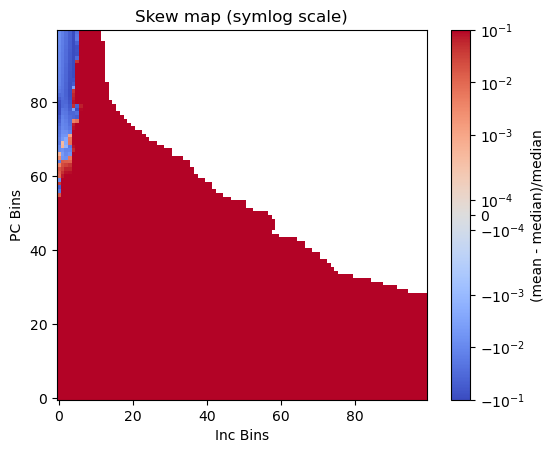

In [23]:
#Check Skewness
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import numpy as np

skew = (BOOT_MEAN - BOOT_MED)/BOOT_MED

# choose scale based on your data
linthresh = np.min(skew[np.where(skew>0)])  # linear region around 0 (tune this)
vmax = np.nanmax(np.abs(skew))

norm = SymLogNorm(
    linthresh=linthresh,
    linscale=1.0,
    vmin=-vmax,
    vmax= vmax,
    base=10
)

plt.imshow(skew, norm=norm, cmap="coolwarm", origin="lower")
plt.ylabel("PC Bins")
plt.xlabel("Inc Bins")
plt.colorbar(label="(mean - median)/median")
plt.title("Skew map (symlog scale)")
plt.show()


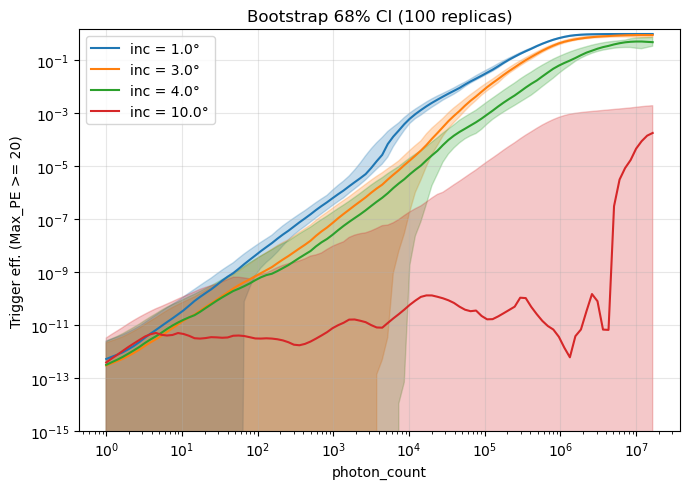

In [24]:
# ---------- Example: efficiency vs photon_count at a few incidences ----------
fig, ax = plt.subplots(figsize=(7, 5))
N_grid = np.logspace(np.log10(pc_.min()), np.log10(pc_.max()), 100)
for inc_val, color in zip([1.0, 3, 4, 10], ['C0', 'C1', 'C2', 'C3', 'C10']):
    eff_c, lo, hi = trigger_eff_ci(N_grid, inc_val)
    ax.plot(N_grid, eff_c, color=color, label=f"inc = {inc_val:.1f}°")
    ax.fill_between(N_grid, lo, hi, color=color, alpha=0.25)
ax.set_xscale('log'); ax.set_ylim(1e-15, 1.5)
ax.set_yscale('log')
ax.set_xlabel("photon_count")
ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
ax.set_title(f"Bootstrap {CI_LEVEL:.0f}% CI ({N_BOOT} replicas)")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


In [25]:
# Empirical efficiency cube on (zenith, H, E) — PARALLEL version
# =============================================================================
import os
import numpy as np
from functools import lru_cache
from joblib import Parallel, delayed
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

# ---------- Config ----------
BOOT_SEED   = 123
N_BOOT_EFF  = 50 #no use
MIN_PTS_EFF = 2
N_E_BINS    = 20
N_H_BINS    = 20
N_Z_BINS    = 20
N_AZ_BINS   = 20
N_JOBS      = os.cpu_count()

ENERGY_MIN = 1e1
ENERGY_MAX = 5e5
ZEN_MIN = 80 #np.nanmin(Zenith)
ZEN_MAX = np.nanmax(Zenith)
AZIMUTH_RANGE = 10.0
H_MIN = 5000
H_MAX = 50000

OBS_HEIGHT_M   = 2944.0
EARTH_RADIUS_M = 6_371_000.0

N_PARAMS = 1
PARAM_ORDER = ["dummy"]
COV_FULL = np.zeros((N_PARAMS, N_PARAMS))

# =============================================================================
# Helpers
# =============================================================================

def eff_vs_zenith_with_ci(pc, zenith_deg_arr, psi_deg, phi_max_deg, n_phi,
                          paired=False):
    """
    Per-shower (median, lo, hi) efficiency averaged over phi, for each zenith.

    Returns
    -------
    eff_out, lo_out, hi_out : each a list (len = n_zen) of arrays shape (Nsh,)
    """
    pc = np.asarray(pc, dtype=float)
    zenith_deg_arr = np.atleast_1d(zenith_deg_arr).astype(float)
    n_zen = len(zenith_deg_arr)

    psi = np.deg2rad(psi_deg)
    phi_max = np.deg2rad(phi_max_deg)
    phi = np.linspace(0, phi_max, n_phi)

    if paired:
        if len(pc) != n_zen:
            raise ValueError("paired=True requires len(pc) == len(zenith_deg_arr)")

    eff_out, lo_out, hi_out = [], [], []

    for k in range(n_zen):
        theta_z = np.deg2rad(zenith_deg_arr[k])
        showers = np.array([pc[k]]) if paired else pc          # (Nsh,)

        # incidence angle grid: (Nsh, n_phi)
        cos_theta = (np.cos(psi) * np.cos(theta_z)
                     + np.sin(psi) * np.sin(theta_z) * np.cos(phi))
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        inc_deg = np.broadcast_to(np.degrees(np.arccos(cos_theta)),
                                  (len(showers), n_phi))
        N_b = np.broadcast_to(showers[:, None], (len(showers), n_phi))

        med, lo, hi = trigger_eff_ci(N_b, inc_deg)             # (Nsh, n_phi)

        # average over phi
        denom = phi[-1] - phi[0]
        eff_out.append(np.trapezoid(med, phi, axis=-1) / denom)
        lo_out.append( np.trapezoid(lo,  phi, axis=-1) / denom)
        hi_out.append( np.trapezoid(hi,  phi, axis=-1) / denom)

    return eff_out, lo_out, hi_out

def _process_bin_slant(k, j, i, pc, zen, psi_deg, phi_max_deg, n_phi,
                       reduce, n_boot, seed):
    """Single (zen, H, E) bin for slant extrapolation."""
    reducer = np.mean if reduce == 'mean' else np.median

    eff_vals, lo_vals, hi_vals = eff_vs_zenith_with_ci(
        pc, np.array([zen], dtype=float), psi_deg, phi_max_deg, n_phi, paired=False
    )
    eff_vals = eff_vals[0]
    lo_vals  = lo_vals[0]
    hi_vals  = hi_vals[0]
    if len(eff_vals) == 0:
        return k, j, i, np.nan, np.nan, np.nan
    return (k, j, i,
            reducer(eff_vals),
            reducer(lo_vals),
            reducer(hi_vals))

# =============================================================================
# 3. Empirical efficiency cube  (parallel over (H, E) bins)
# =============================================================================
def _process_bin_HE(k, j, i, zen_deg, pc_sel, psi_deg, phi_max_deg, n_phi):
    if len(pc_sel) == 0:
        return k, j, i, np.nan, np.nan, np.nan
    theta_z = np.radians(zen_deg)
    psi = np.radians(psi_deg)
    phi = np.linspace(0.0, np.radians(phi_max_deg), n_phi)

    cos_t = (np.cos(psi)*np.cos(theta_z)
             + np.sin(psi)*np.sin(theta_z)*np.cos(phi))
    cos_t = np.clip(cos_t, -1.0, 1.0)
    theta_inc = np.degrees(np.arccos(cos_t))           # (n_phi,)

    npts = len(pc_sel)
    pc_b  = pc_sel[:, None]                            # (Nsh, 1)
    inc_b = np.broadcast_to(theta_inc, (npts, n_phi))  # (Nsh, n_phi)
    med, lo, hi = trigger_eff_ci(pc_b, inc_b)          # (Nsh, n_phi)

    denom = phi[-1] - phi[0]
    med_phi = np.trapezoid(med, phi, axis=-1) / denom
    lo_phi  = np.trapezoid(lo,  phi, axis=-1) / denom
    hi_phi  = np.trapezoid(hi,  phi, axis=-1) / denom
    return k, j, i, np.mean(med_phi), np.mean(lo_phi), np.mean(hi_phi)

def efficiency_grid_H_E(
    E_edges, H_edges, Zen_grid,
    Energy_GeV, H, photon_count,
    psi_deg=90.0, phi_max_deg=3.0, n_phi=50,
    min_pts=5, reduce='mean',
    n_boot=200, rng=None, n_jobs=1,
):
    n_zen = len(Zen_grid)
    n_H   = len(H_edges) - 1
    n_E   = len(E_edges) - 1
    E_cen = np.sqrt(E_edges[:-1] * E_edges[1:])
    H_cen = 0.5 * (H_edges[:-1] + H_edges[1:])

    EFF     = np.full((n_zen, n_H, n_E), np.nan)
    EFF_LO  = np.full((n_zen, n_H, n_E), np.nan)
    EFF_HI  = np.full((n_zen, n_H, n_E), np.nan)
    COUNTS  = np.zeros((n_zen, n_H, n_E), dtype=int)
    GRAD    = np.zeros((n_zen, n_H, n_E, N_PARAMS))
    pc_in_bin = [[[None]*n_E for _ in range(n_H)] for _ in range(n_zen)]

    # Build tasks
    tasks = []
    for k, zen_deg in enumerate(Zen_grid):
        for i in range(n_E):
            in_E = (Energy_GeV >= E_edges[i]) & (Energy_GeV < E_edges[i+1])
            for j in range(n_H):
                sel = in_E & (H >= H_edges[j]) & (H < H_edges[j+1])
                npts = int(np.sum(sel))
                COUNTS[k, j, i] = npts
                if npts < min_pts:
                    continue
                pc_sel = photon_count[sel]
                pc_in_bin[k][j][i] = pc_sel
                tasks.append((k, j, i, zen_deg, pc_sel))

    if not tasks:
        return (EFF, EFF_LO, EFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD)

    print(f"efficiency_grid_H_E: {len(tasks)} bins on {n_jobs} CPUs")
    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(_process_bin_HE)(k, j, i, zen_deg, pc_sel,
                                 psi_deg, phi_max_deg, n_phi)
        for (k, j, i, zen_deg, pc_sel) in tasks
    )

    for k, j, i, eff_v, lo_v, hi_v in results:
        EFF[k, j, i]    = eff_v
        EFF_LO[k, j, i] = lo_v
        EFF_HI[k, j, i] = hi_v

    return (EFF, EFF_LO, EFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD)

# =============================================================================
# 4. Build (E, Slant) photon-count lookup
# =============================================================================
def build_E_slant_pc_table(E_edges, H_emit, Energy_GeV, photon_count,
                           Zenith_deg, n_slant_bins):
    E_edges = np.asarray(E_edges, dtype=float)
    H_emit = np.asarray(H_emit, dtype=float)
    Energy_GeV = np.asarray(Energy_GeV, dtype=float)
    photon_count = np.asarray(photon_count, dtype=float)
    Zenith_rad = np.radians(np.asarray(Zenith_deg, dtype=float))

    Slant_km = slant_depth(
        H_emit + EARTH_RADIUS_M,
        OBS_HEIGHT_M + EARTH_RADIUS_M,
        Zenith_rad,
    ) / 1000.0

    S_edges = np.linspace(np.nanmin(Slant_km), np.nanmax(Slant_km), n_slant_bins + 1)
    S_cen = 0.5 * (S_edges[:-1] + S_edges[1:])

    n_E = len(E_edges) - 1
    pc_ES = [[None] * n_slant_bins for _ in range(n_E)]
    for i in range(n_E):
        in_E = (Energy_GeV >= E_edges[i]) & (Energy_GeV < E_edges[i + 1])
        for s in range(n_slant_bins):
            mask = in_E & (Slant_km >= S_edges[s]) & (Slant_km < S_edges[s + 1])
            pc = photon_count[mask]
            pc_ES[i][s] = pc[np.isfinite(pc) & (pc > 0)]
    return S_edges, S_cen, pc_ES

# =============================================================================
# 5. Slant-based extrapolation  (parallel over empty cells)
# =============================================================================
def extrapolate_via_slant(EFF, EFF_LO, EFF_HI,
                          E_cen, H_cen, zenith_deg, S_edges, pc_ES,
                          psi_deg=90.0, phi_max_deg=5.0, n_phi=20,
                          min_pts=5, reduce='mean', n_boot=200,
                          rng=None, n_jobs=N_JOBS):
    if rng is None:
        rng = np.random.default_rng()
    ss = np.random.SeedSequence(rng.integers(0, 2**31 - 1))

    n_zen, n_H, n_E = EFF.shape
    tasks = []
    for k in range(n_zen):
        zen = zenith_deg[k]
        for j in range(n_H):
            slant_km = slant_depth(
                H_cen[j] + EARTH_RADIUS_M,
                OBS_HEIGHT_M + EARTH_RADIUS_M,
                np.deg2rad(zen),
            ) / 1000.0
            si = int(np.clip(np.searchsorted(S_edges, slant_km) - 1,
                             0, len(S_edges) - 2))
            for i in range(n_E):
                if np.isfinite(EFF[k, j, i]):
                    continue
                pc = pc_ES[i][si]
                if pc is None or len(pc) < min_pts:
                    continue
                tasks.append((k, j, i, pc, zen))

    if not tasks:
        return EFF, EFF_LO, EFF_HI

    seeds = [s.generate_state(1)[0] for s in ss.spawn(len(tasks))]
    print(f"extrapolate_via_slant: {len(tasks)} bins on {n_jobs} CPUs")
    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(_process_bin_slant)(
            k, j, i, pc, zen, psi_deg, phi_max_deg, n_phi,
            reduce, n_boot, seed)
        for (k, j, i, pc, zen), seed in zip(tasks, seeds)
    )

    for k, j, i, eff_val, lo_val, hi_val in results:
        if np.isfinite(eff_val):
            EFF[k, j, i]    = eff_val
            EFF_LO[k, j, i] = lo_val
            EFF_HI[k, j, i] = hi_val
    return EFF, EFF_LO, EFF_HI

# =============================================================================
# 6. Build efficiency interpolator (unchanged logic)
# =============================================================================
def build_efficiency_interpolator(EFF, EFF_LO, EFF_HI,
                                  E_cen, H_cen, zenith_deg, S_edges, pc_ES,
                                  psi_deg=90.0, phi_max_deg=5.0, n_phi=20,
                                  min_pts=3, reduce='mean', n_boot=200,
                                  rng=None,
                                  H_extrap_range=(0.0, 120_000.0),
                                  n_H_extra=4,
                                  zen_extrap_range=None,
                                  n_zen_extra=2,
                                  n_jobs=N_JOBS):
    H_cen = np.asarray(H_cen, dtype=float)
    zenith_deg = np.asarray(zenith_deg, dtype=float)

    if n_H_extra > 0:
        H_lo = np.linspace(H_extrap_range[0], H_cen[0],  n_H_extra + 1)[:-1]
        H_hi = np.linspace(H_cen[-1], H_extrap_range[1], n_H_extra + 1)[1:]
        H_cen_ext = np.concatenate([H_lo, H_cen, H_hi])
    else:
        H_cen_ext = H_cen.copy()

    if zen_extrap_range is not None and n_zen_extra > 0:
        Z_lo = np.linspace(zen_extrap_range[0], zenith_deg[0],  n_zen_extra + 1)[:-1]
        Z_hi = np.linspace(zenith_deg[-1], zen_extrap_range[1], n_zen_extra + 1)[1:]
        zen_ext = np.concatenate([Z_lo, zenith_deg, Z_hi])
    else:
        zen_ext = zenith_deg.copy()

    z_off = int(np.searchsorted(zen_ext, zenith_deg[0]))
    h_off = int(np.searchsorted(H_cen_ext, H_cen[0]))
    n_zen_ext = len(zen_ext)
    n_H_ext   = len(H_cen_ext)
    n_E       = EFF.shape[2]

    def _embed(arr_old):
        out = np.full((n_zen_ext, n_H_ext, n_E), np.nan)
        out[z_off:z_off+len(zenith_deg), h_off:h_off+len(H_cen), :] = arr_old
        return out

    EFF    = _embed(EFF)
    EFF_LO = _embed(EFF_LO)
    EFF_HI = _embed(EFF_HI)

    H_cen      = H_cen_ext
    zenith_deg = zen_ext

    EFF_filled    = EFF.copy()
    EFF_LO_filled = EFF_LO.copy()
    EFF_HI_filled = EFF_HI.copy()
    fill_mask = ~np.isfinite(EFF)

    nan_mask = ~np.isfinite(EFF_filled)
    if np.any(nan_mask):
        _, idx = distance_transform_edt(nan_mask, return_indices=True)
        EFF_filled[nan_mask]    = EFF_filled[tuple(idx)][nan_mask]
        EFF_LO_filled[nan_mask] = EFF_LO_filled[tuple(idx)][nan_mask]
        EFF_HI_filled[nan_mask] = EFF_HI_filled[tuple(idx)][nan_mask]

    original_nan = ~np.isfinite(EFF)
    edge_mask = np.zeros_like(EFF_filled, dtype=bool)
    edge_mask[:, :2, :]  = True
    edge_mask[:2, :, :]  = True
    edge_mask[-2:, :, :] = True
    reopen = edge_mask & original_nan
    EFF_filled[reopen]    = np.nan
    EFF_LO_filled[reopen] = np.nan
    EFF_HI_filled[reopen] = np.nan

    EFF_filled, EFF_LO_filled, EFF_HI_filled = extrapolate_via_slant(
        EFF_filled, EFF_LO_filled, EFF_HI_filled,
        E_cen, H_cen, zenith_deg, S_edges, pc_ES,
        psi_deg=psi_deg, phi_max_deg=phi_max_deg, n_phi=n_phi,
        min_pts=min_pts, reduce=reduce, n_boot=n_boot, rng=rng,
        n_jobs=n_jobs,
    )

    remaining = ~np.isfinite(EFF_filled)
    if np.any(remaining):
        _, idx2 = distance_transform_edt(remaining, return_indices=True)
        EFF_filled[remaining]    = EFF_filled[tuple(idx2)][remaining]
        EFF_LO_filled[remaining] = EFF_LO_filled[tuple(idx2)][remaining]
        EFF_HI_filled[remaining] = EFF_HI_filled[tuple(idx2)][remaining]

    EFF_filled[~np.isfinite(EFF_filled)]       = 0.0
    EFF_LO_filled[~np.isfinite(EFF_LO_filled)] = 0.0
    EFF_HI_filled[~np.isfinite(EFF_HI_filled)] = 0.0

    log10_E = np.log10(E_cen)
    rgi_eff = RegularGridInterpolator((zenith_deg, H_cen, log10_E),
                                      EFF_filled, method='linear',
                                      bounds_error=False, fill_value=None)
    rgi_lo  = RegularGridInterpolator((zenith_deg, H_cen, log10_E),
                                      EFF_LO_filled, method='linear',
                                      bounds_error=False, fill_value=None)
    rgi_hi  = RegularGridInterpolator((zenith_deg, H_cen, log10_E),
                                      EFF_HI_filled, method='linear',
                                      bounds_error=False, fill_value=None)
    rgi_mask = RegularGridInterpolator((zenith_deg, H_cen, log10_E),
                                       fill_mask.astype(float), method='nearest',
                                       bounds_error=False, fill_value=1.0)

    def eff_func(E_GeV, H_m, zenith_deg_q):
        E_b, H_b, Z_b = np.broadcast_arrays(
            np.asarray(E_GeV, float), np.asarray(H_m, float), np.asarray(zenith_deg_q, float))
        pts = np.column_stack([Z_b.ravel(), H_b.ravel(), np.log10(E_b.ravel())])
        return np.clip(rgi_eff(pts), 0.0, 1.0).reshape(E_b.shape)

    def eff_sigma_func(E_GeV, H_m, zenith_deg_q):
        """Returns (median, lo, hi)."""
        E_b, H_b, Z_b = np.broadcast_arrays(
            np.asarray(E_GeV, float), np.asarray(H_m, float), np.asarray(zenith_deg_q, float))
        pts = np.column_stack([Z_b.ravel(), H_b.ravel(), np.log10(E_b.ravel())])
        med = np.clip(rgi_eff(pts), 0.0, 1.0).reshape(E_b.shape)
        lo  = np.clip(rgi_lo(pts),  0.0, 1.0).reshape(E_b.shape)
        hi  = np.clip(rgi_hi(pts),  0.0, 1.0).reshape(E_b.shape)
        return med, lo, hi

    def eff_fill_mask_func(E_GeV, H_m, zenith_deg_q):
        E_b, H_b, Z_b = np.broadcast_arrays(
            np.asarray(E_GeV, float), np.asarray(H_m, float), np.asarray(zenith_deg_q, float))
        pts = np.column_stack([Z_b.ravel(), H_b.ravel(), np.log10(E_b.ravel())])
        return (rgi_mask(pts).reshape(E_b.shape) >= 0.5)

    extra = {
        "EFF_filled": EFF_filled,
        "EFF_LO_filled": EFF_LO_filled,
        "EFF_HI_filled": EFF_HI_filled,
        "fill_mask": fill_mask,
        "H_cen_ext": H_cen, "zen_ext": zenith_deg,
    }
    return eff_func, eff_sigma_func, eff_fill_mask_func, extra

def ffill_along_H(EFF, *extras):
    n_zen, n_H, n_E = EFF.shape
    out = EFF.copy()
    extra_outs = [arr.copy() for arr in extras]
    for k in range(n_zen):
        for i in range(n_E):
            col = out[k, :, i]
            finite = np.isfinite(col)
            if not finite.any():
                continue
            idx = np.where(finite, np.arange(n_H), 0)
            np.maximum.accumulate(idx, out=idx)
            out[k, :, i] = col[idx]
            for arr_out in extra_outs:
                arr_out[k, :, i, ...] = arr_out[k, idx, i, ...]
    if extra_outs:
        return (out, *extra_outs)
    return out

# =============================================================================
# Driver
# =============================================================================
rng = np.random.default_rng(BOOT_SEED)
E_edges = np.logspace(np.log10(ENERGY_MIN), np.log10(ENERGY_MAX), N_E_BINS + 1)
H_edges = np.linspace(H_MIN, H_MAX, N_H_BINS + 1)
Zen_grid = np.linspace(ZEN_MIN, ZEN_MAX, N_Z_BINS)

(EFF, EFF_LO, EFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD) = efficiency_grid_H_E(
    E_edges, H_edges, Zen_grid,
    Energy_GeV, H, photon_count,
    psi_deg=90.0, phi_max_deg=AZIMUTH_RANGE, n_phi=N_AZ_BINS,
    min_pts=MIN_PTS_EFF, reduce='mean',
    n_boot=N_BOOT_EFF, rng=rng, n_jobs=N_JOBS,
)

# Forward-fill along H for EFF, EFF_LO, EFF_HI (and GRAD if you still need it)
EFF, EFF_LO, EFF_HI, GRAD = ffill_along_H(EFF, EFF_LO, EFF_HI, GRAD)

S_edges, S_cen, pc_ES = build_E_slant_pc_table(
    E_edges, H, Energy_GeV, photon_count, Zenith,
    n_slant_bins=N_H_BINS,
)

eff_func, eff_sigma_func, eff_fill_mask_func, eff_extra = build_efficiency_interpolator(
    EFF, EFF_LO, EFF_HI, E_cen, H_cen, Zen_grid, S_edges, pc_ES,
    psi_deg=90.0, phi_max_deg=AZIMUTH_RANGE, n_phi=N_AZ_BINS,
    min_pts=MIN_PTS_EFF, reduce='mean',
    n_boot=N_BOOT_EFF, rng=rng, n_jobs=N_JOBS,
)


efficiency_grid_H_E: 7600 bins on 56 CPUs


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done  50 tasks      | elapsed:    0.1s
[Parallel(n_jobs=56)]: Done 240 tasks      | elapsed:    0.7s
[Parallel(n_jobs=56)]: Done 564 tasks      | elapsed:    1.4s
[Parallel(n_jobs=56)]: Done 960 tasks      | elapsed:    2.3s
[Parallel(n_jobs=56)]: Done 1428 tasks      | elapsed:    3.3s
[Parallel(n_jobs=56)]: Done 1968 tasks      | elapsed:    4.5s
[Parallel(n_jobs=56)]: Done 2580 tasks      | elapsed:    5.9s
[Parallel(n_jobs=56)]: Done 3264 tasks      | elapsed:    7.5s
[Parallel(n_jobs=56)]: Done 4020 tasks      | elapsed:    9.1s
[Parallel(n_jobs=56)]: Done 4848 tasks      | elapsed:   10.9s
[Parallel(n_jobs=56)]: Done 5748 tasks      | elapsed:   12.8s
[Parallel(n_jobs=56)]: Done 6720 tasks      | elapsed:   15.0s
[Parallel(n_jobs=56)]: Done 7600 out of 7600 | elapsed:   17.0s finished


extrapolate_via_slant: 1199 bins on 56 CPUs


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done  50 tasks      | elapsed:    0.2s
[Parallel(n_jobs=56)]: Done 240 tasks      | elapsed:    0.6s
[Parallel(n_jobs=56)]: Done 564 tasks      | elapsed:    1.2s
[Parallel(n_jobs=56)]: Done 960 tasks      | elapsed:    1.7s
[Parallel(n_jobs=56)]: Done 1088 out of 1199 | elapsed:    1.9s remaining:    0.2s
[Parallel(n_jobs=56)]: Done 1199 out of 1199 | elapsed:    2.1s finished


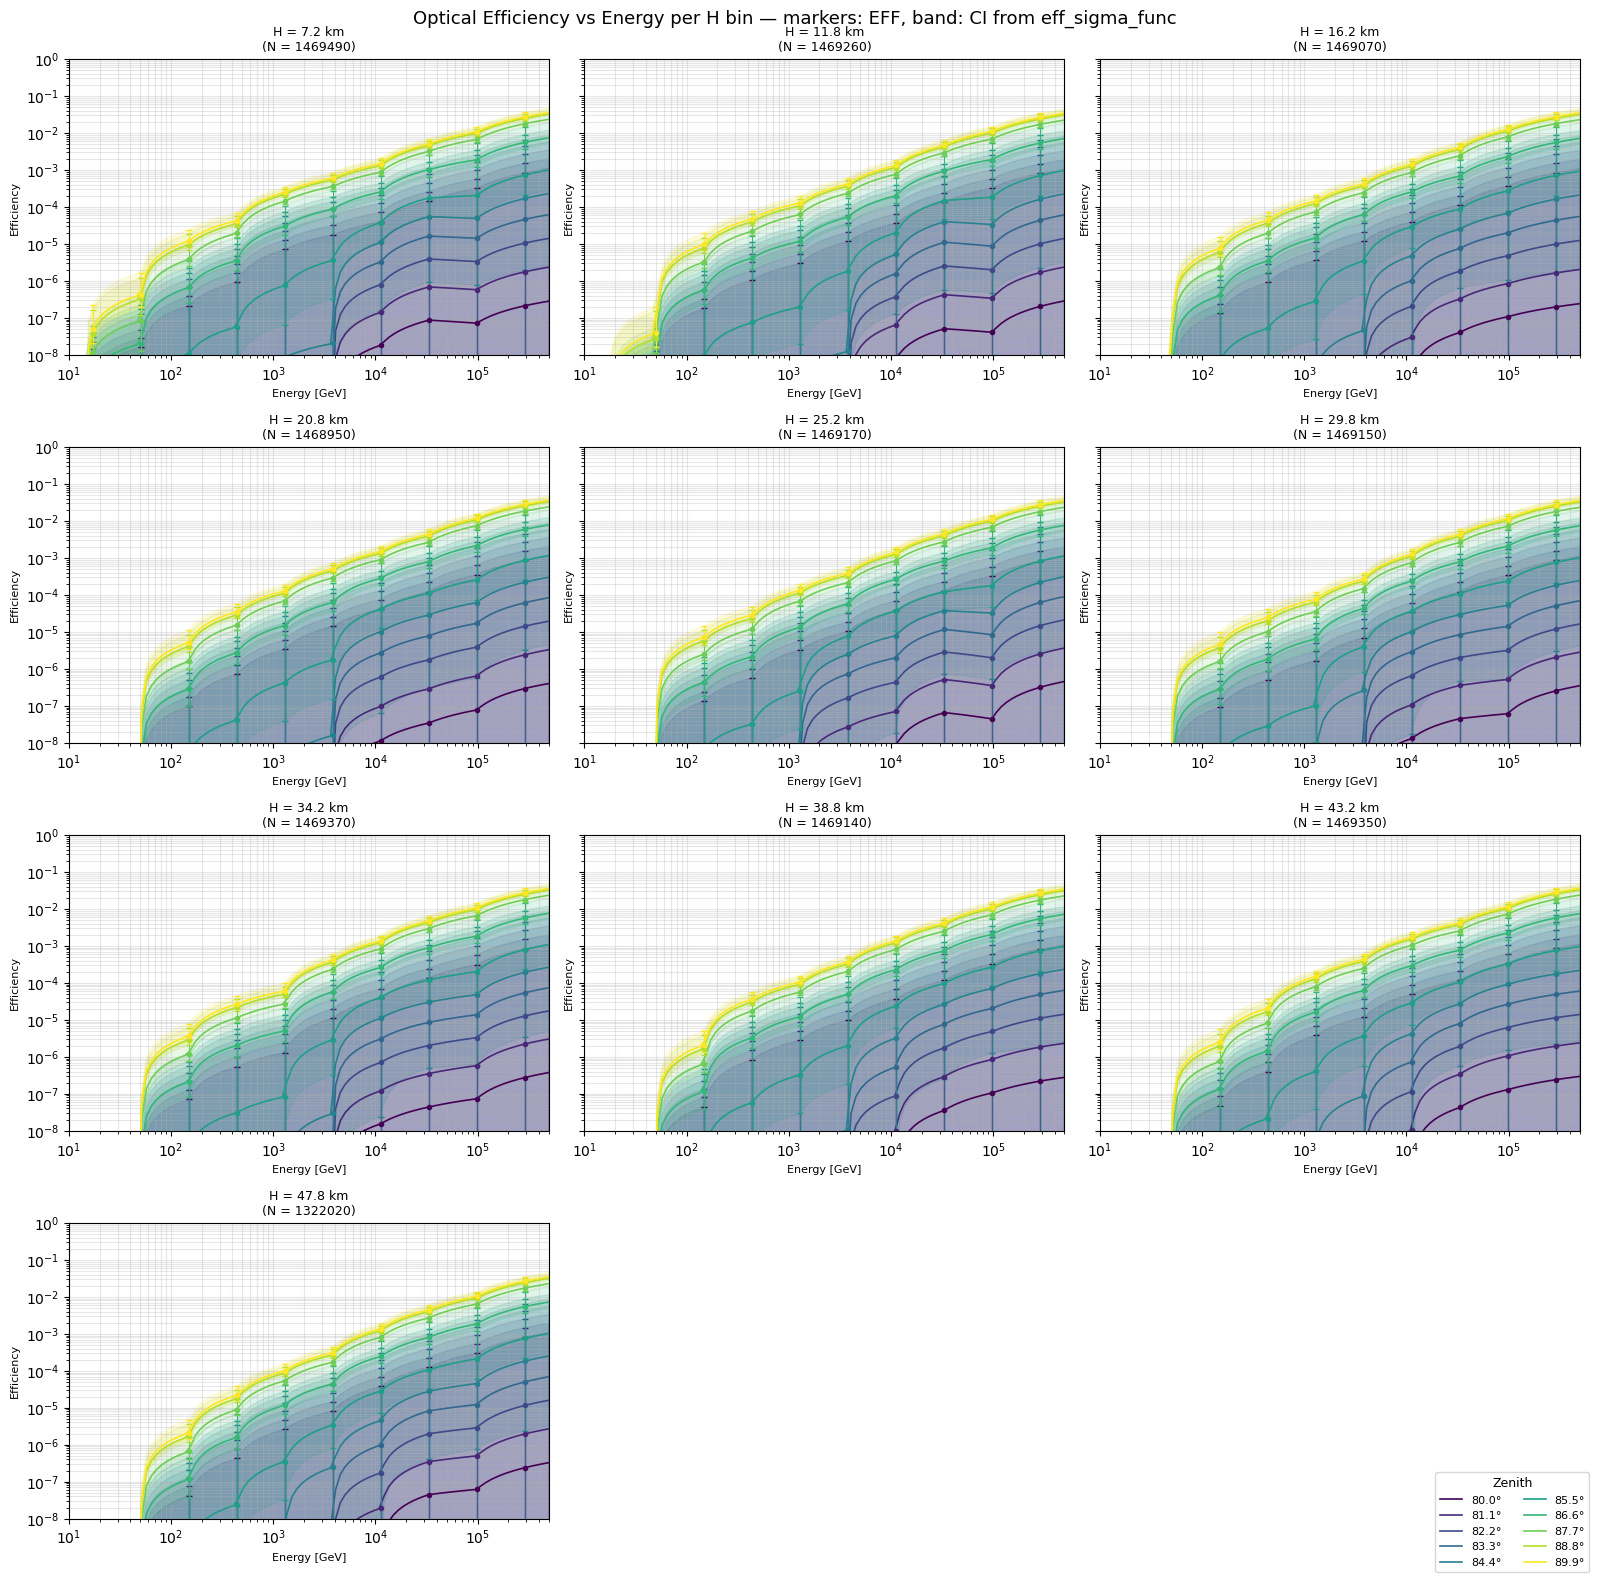

In [93]:
# Testing plot
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

n_H = len(H_cen)
n_Z = len(Zen_grid)

ncols = 3
nrows = int(np.ceil(n_H / ncols))

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(16, 4 * nrows),
    sharey=True,
)
axes = np.atleast_1d(axes).ravel()

colors = cm.viridis(np.linspace(0, 1, n_Z))

E_plot = np.logspace(np.log10(E_edges[0]), np.log10(E_edges[-1]), 100)

for j in range(n_H):
    ax = axes[j]
    H_val = H_cen[j]

    for k, zen in enumerate(Zen_grid):
        # --- interpolator (smooth line + CI band) ---
        med_curve, lo_curve, hi_curve = eff_sigma_func(
            E_plot,
            np.full_like(E_plot, H_val),
            np.full_like(E_plot, zen),
        )

        ax.plot(
            E_plot, med_curve,
            color=colors[k],
            linestyle='-',
            linewidth=1.2,
            label=f"{zen:.1f}°",
        )
        ax.fill_between(E_plot, lo_curve, hi_curve,
                        color=colors[k], alpha=0.15)

        # --- raw EFF with asymmetric error bars (markers) ---
        eff_row = EFF[k, j, :]
        valid = np.isfinite(eff_row)
        if valid.any():
            med_pts, lo_pts, hi_pts = eff_sigma_func(
                E_cen[valid],
                np.full_like(E_cen[valid], H_val),
                np.full_like(E_cen[valid], zen),
            )
            yerr = np.vstack([
                np.clip(eff_row[valid] - lo_pts, 0, None),
                np.clip(hi_pts - eff_row[valid], 0, None),
            ])
            ax.errorbar(
                E_cen[valid], eff_row[valid],
                yerr=yerr,
                color=colors[k],
                marker='o',
                markersize=3,
                linestyle='none',
                elinewidth=0.8,
                capsize=2,
            )

    ax.set_xscale('log')
    ax.set_xlim(E_edges[0], E_edges[-1])
    ax.set_ylim(1e-8, 1)
    ax.set_yscale("log")
    ax.set_title(
        f"H = {H_cen[j]/1e3:.1f} km\n"
        f"(N = {COUNTS[:, j, :].sum()})",
        fontsize=9,
    )
    ax.set_xlabel("Energy [GeV]", fontsize=8)
    ax.set_ylabel("Efficiency",   fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Zenith",
    loc='lower right',
    ncol=2,
    fontsize=8,
    title_fontsize=9,
    bbox_to_anchor=(1.0, 0.0),
)

for j in range(n_H, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Optical Efficiency vs Energy per H bin — markers: EFF, band: CI from eff_sigma_func",
             fontsize=13)
plt.tight_layout()
plt.show()


Extending from largest zenith 89.9503° up to 92.0°
Total zenith bins after extension: 120 (range 91.950° → 80.051°)


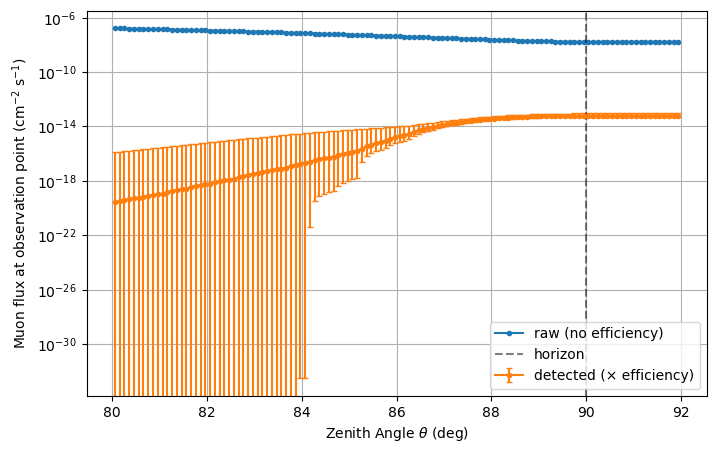

Slope     m = -3.588042e-03 ± 8.871475e-05
Intercept b = 2.258685e-02 ± 3.836463e-04
Weighted R² = 0.99332
Effective Area (central) = 412328.7528 cm²
Effective Area (MC mean) = 4131805284.57 ± 83436645.37 cm²


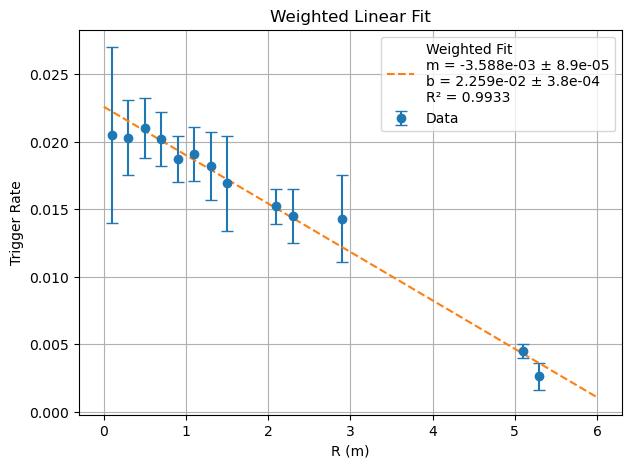


--- Muon Rates per Hour ---
Total (raw, no efficiency):  10694.033930401229
Detected (central):          0.0039274167647937504
  ± eff uncertainty (lo/hi): -0.0008112593123696517 / +0.002212228583723025
  ± area uncertainty:        ±7.930927458005334e-05
  ± combined (lo/hi):        -0.0008151267588178506 / +0.002213649761745429

Final: 0.0039274167647937504  [0.0031122900059758997, 0.006141066526539179]  muons/hour


In [31]:
# Extrapolate to high zenith
import pickle
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 2. Load the precomputed MCEq grid
# =========================================================================
with open('/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/'
          'mceq_grid_80_90deg.pkl', 'rb') as f:
    grid_data = pickle.load(f)

zen_centers_all = grid_data['zen_centers']
cos_edges       = grid_data['cos_edges']
E_GeV           = grid_data['E_GeV']
min_E           = grid_data['min_E']
max_E           = grid_data['max_E']

zen_min_use, zen_max_use = 80, 90.0

zen_mask = (zen_centers_all >= zen_min_use) & (zen_centers_all <= zen_max_use)
if not np.any(zen_mask):
    raise ValueError(
        f"No zenith bins in [{zen_min_use}, {zen_max_use}] deg. "
        f"Available centers: {zen_centers_all}"
    )

zen_centers = zen_centers_all[zen_mask]

tele_azimuth = 270
min_az, max_az = tele_azimuth - AZIMUTH_RANGE, tele_azimuth + AZIMUTH_RANGE
dphi = np.radians(max_az - min_az)
dcos = np.diff(cos_edges)
solid_angles_all = dphi * np.abs(dcos)
solid_angles     = solid_angles_all[zen_mask]

selected_entries = [e for e, keep in zip(grid_data['per_zenith'], zen_mask) if keep]

# =========================================================================
# 2b. EXTEND to 92°
# =========================================================================
extend_to_deg   = 92.0
extra_bin_width = 0.1

idx_max = int(np.argmax(zen_centers))
last_entry = selected_entries[idx_max]
last_theta = last_entry['theta']
print(f"Extending from largest zenith {last_theta:.4f}° up to {extend_to_deg}°")

extra_centers = np.arange(last_theta + extra_bin_width,
                          extend_to_deg + 1e-9,
                          extra_bin_width)

extra_solid_angles = []
for zc in extra_centers:
    c_lo = np.cos(np.radians(zc - extra_bin_width/2))
    c_hi = np.cos(np.radians(zc + extra_bin_width/2))
    extra_solid_angles.append(dphi * abs(c_lo - c_hi))
extra_solid_angles = np.array(extra_solid_angles)

extra_entries = []
for zc in extra_centers:
    extra_entries.append({
        'theta':    zc,
        'd_CDF':    last_entry['d_CDF'],
        'H_grid':   last_entry['H_grid'],
        'sum_mceq': last_entry['sum_mceq'],
    })

zen_centers      = np.concatenate([zen_centers, extra_centers])
solid_angles     = np.concatenate([solid_angles, extra_solid_angles])
selected_entries = selected_entries + extra_entries

order = np.argsort(zen_centers)[::-1]
zen_centers      = zen_centers[order]
solid_angles     = solid_angles[order]
selected_entries = [selected_entries[i] for i in order]

print(f"Total zenith bins after extension: {len(zen_centers)} "
      f"(range {zen_centers[0]:.3f}° → {zen_centers[-1]:.3f}°)")

# =========================================================================
# 3. Loop over zenith and apply efficiency via eff_func / eff_sigma_func
# =========================================================================
Total_flux_raw           = []
Total_flux_detected2     = []
Total_flux_detected2_lo  = []
Total_flux_detected2_hi  = []
eff_map     = []
eff_map_lo  = []
eff_map_hi  = []

for i, entry in enumerate(selected_entries):
    theta    = entry['theta']
    d_CDF    = entry['d_CDF']
    H_grid   = entry['H_grid']
    sum_mceq = entry['sum_mceq']
    H_m = H_grid / 100.0
    Solid_angle = solid_angles[i]

    theta_q = min(theta, Zen_grid[-1])

    H_mesh, E_mesh = np.meshgrid(H_m, E_GeV, indexing='ij')
    Z_mesh = np.full_like(H_mesh, theta_q)

    eff_HE2 = eff_func(E_mesh, H_mesh, Z_mesh)
    eff_HE2 = np.nan_to_num(eff_HE2, nan=0.0)

    med_HE2, lo_HE2, hi_HE2 = eff_sigma_func(E_mesh, H_mesh, Z_mesh)
    lo_HE2 = np.nan_to_num(lo_HE2, nan=0.0)
    hi_HE2 = np.nan_to_num(hi_HE2, nan=0.0)

    E_mask = (E_GeV >= min_E) & (E_GeV <= max_E)

    CDF = np.cumsum(d_CDF, axis=0)
    CDF_positive = np.cumsum(np.clip(d_CDF, 0, None), axis=0)
    survival_prob_per_E = CDF[-1] / CDF_positive[-1]

    integrand_HE2 = np.clip(d_CDF, 0, None) * eff_HE2 * survival_prob_per_E
    d_CDF_det_E   = np.trapezoid(integrand_HE2[:, E_mask], E_GeV[E_mask], axis=1)
    detected_at_ground2 = np.cumsum(d_CDF_det_E, axis=0)[-1]

    integrand_lo = np.clip(d_CDF, 0, None) * lo_HE2 * survival_prob_per_E
    integrand_hi = np.clip(d_CDF, 0, None) * hi_HE2 * survival_prob_per_E
    d_CDF_det_E_lo = np.trapezoid(integrand_lo[:, E_mask], E_GeV[E_mask], axis=1)
    d_CDF_det_E_hi = np.trapezoid(integrand_hi[:, E_mask], E_GeV[E_mask], axis=1)
    detected_lo = np.cumsum(d_CDF_det_E_lo, axis=0)[-1]
    detected_hi = np.cumsum(d_CDF_det_E_hi, axis=0)[-1]

    weights = survival_prob_per_E * np.clip(d_CDF, 0, None)
    weight_sum = weights.sum(axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        eff_vs_E = np.where(
            weight_sum > 0,
            (weights * eff_HE2).sum(axis=0) / weight_sum,
            np.nan,
        )
        eff_vs_E_lo = np.where(
            weight_sum > 0,
            (weights * lo_HE2).sum(axis=0) / weight_sum,
            np.nan,
        )
        eff_vs_E_hi = np.where(
            weight_sum > 0,
            (weights * hi_HE2).sum(axis=0) / weight_sum,
            np.nan,
        )

    cos_factor = 1
    Total_flux_raw.append(          sum_mceq            * Solid_angle * cos_factor)
    Total_flux_detected2.append(    detected_at_ground2 * Solid_angle * cos_factor)
    Total_flux_detected2_lo.append( detected_lo         * Solid_angle * cos_factor)
    Total_flux_detected2_hi.append( detected_hi         * Solid_angle * cos_factor)
    eff_map.append(eff_vs_E)
    eff_map_lo.append(eff_vs_E_lo)
    eff_map_hi.append(eff_vs_E_hi)

Total_flux_raw          = np.array(Total_flux_raw)
Total_flux_detected2    = np.array(Total_flux_detected2)
Total_flux_detected2_lo = np.array(Total_flux_detected2_lo)
Total_flux_detected2_hi = np.array(Total_flux_detected2_hi)
eff_map    = np.array(eff_map)
eff_map_lo = np.array(eff_map_lo)
eff_map_hi = np.array(eff_map_hi)

# --- Plot vs zenith ---
plt.figure(figsize=(8,5))
plt.plot(zen_centers, Total_flux_raw, '.-', label='raw (no efficiency)')
yerr = np.vstack([
    np.clip(Total_flux_detected2 - Total_flux_detected2_lo, 0, None),
    np.clip(Total_flux_detected2_hi - Total_flux_detected2, 0, None),
])
plt.errorbar(zen_centers, Total_flux_detected2,
             yerr=yerr,
             fmt='.-', capsize=2,
             label='detected (× efficiency)')
plt.axvline(90, color='k', ls='--', alpha=0.5, label='horizon')
plt.xlabel(r'Zenith Angle $\theta$ (deg)')
plt.ylabel(r'Muon flux at observation point (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log'); plt.legend(); plt.grid(); plt.show()

# =========================================================================
# 4. Effective area from digitized trigger-rate data
# =========================================================================

# --- Digitized data ---
R_data = np.array([
    0.10, 0.30, 0.50, 0.70, 0.90,
    1.10, 1.30, 1.50, 2.10, 2.30,
    2.90, 5.10, 5.30
])

trigger_data = np.array([
    0.0205, 0.0203, 0.0210, 0.0202,
    0.0187, 0.0191, 0.0182, 0.0169,
    0.0152, 0.0145, 0.0143,
    0.0045, 0.0026
])

trigger_rate_err = np.array([
    0.0065, 0.0028, 0.0022, 0.0020,
    0.0017, 0.0020, 0.0025, 0.0035,
    0.0013, 0.0020, 0.0032, 0.0005,
    0.0010
])

# --- Weighted linear fit ---
fit_weights = 1.0 / trigger_rate_err**2

(p, cov_fit) = np.polyfit(
    R_data,
    trigger_data,
    deg=1,
    w=np.sqrt(fit_weights),
    cov=True
)

m_fit, b_fit = p
m_err = np.sqrt(cov_fit[0, 0])
b_err = np.sqrt(cov_fit[1, 1])

print(f"Slope     m = {m_fit:.6e} ± {m_err:.6e}")
print(f"Intercept b = {b_fit:.6e} ± {b_err:.6e}")

# --- Weighted R² ---
y_fit        = m_fit * R_data + b_fit
weighted_mean = np.average(trigger_data, weights=fit_weights)
ss_res = np.sum(fit_weights * (trigger_data - y_fit)**2)
ss_tot = np.sum(fit_weights * (trigger_data - weighted_mean)**2)
r_squared = 1 - ss_res / ss_tot
print(f"Weighted R² = {r_squared:.5f}")

# --- Central effective area ---
r_grid = np.linspace(0, 6, 10000)
trigger_rate_r      = np.clip(m_fit * r_grid + b_fit, 0, None)
trigger_rate_r_norm = trigger_rate_r / trigger_rate_r.max()
effective_area_central = 2 * np.pi * np.trapezoid(
    trigger_rate_r_norm * r_grid, x=r_grid
)
print(f"Effective Area (central) = {effective_area_central * 1e4:.4f} cm²")

# --- Monte Carlo uncertainty propagation ---
N_mc = 1000
samples = np.random.multivariate_normal(
    mean=[m_fit, b_fit],
    cov=cov_fit,
    size=N_mc
)

area_samples = []
for m_i, b_i in samples:
    trigger_i = np.clip(m_i * r_grid + b_i, 0, None)
    if trigger_i.max() <= 0:
        continue
    trigger_i_norm = trigger_i / trigger_i.max()
    area_i = 2 * np.pi * np.trapezoid(trigger_i_norm * r_grid, x=r_grid)
    area_samples.append(area_i)

area_samples = np.array(area_samples) * 1e4 #convert to cm^2

effective_area_mean = np.mean(area_samples) 
effective_area_std  = np.std(area_samples) 

print(f"Effective Area (MC mean) = {effective_area_mean * 1e4:.2f} ± "
      f"{effective_area_std * 1e4:.2f} cm²")

# --- Fit plot ---
plt.figure(figsize=(7, 5))
plt.errorbar(R_data, trigger_data, yerr=trigger_rate_err,
             fmt='o', capsize=4, label='Data')
plt.plot(r_grid, m_fit * r_grid + b_fit, '--',
         label=(f'Weighted Fit\n'
                f'm = {m_fit:.3e} ± {m_err:.1e}\n'
                f'b = {b_fit:.3e} ± {b_err:.1e}\n'
                f'R² = {r_squared:.4f}'))
plt.xlabel("R (m)")
plt.ylabel("Trigger Rate")
plt.title("Weighted Linear Fit")
plt.grid(True)
plt.legend()
plt.show()

# =========================================================================
# 5. Muon rates with combined efficiency + effective-area uncertainties
# =========================================================================

# Summed fluxes (units: cm⁻² s⁻¹ sr⁻¹  ×  sr  →  cm⁻² s⁻¹)
flux_central = np.sum(Total_flux_detected2)
flux_lo      = np.sum(Total_flux_detected2_lo)
flux_hi      = np.sum(Total_flux_detected2_hi)
flux_raw     = np.sum(Total_flux_raw)

# Central rates  (× effective area [cm²] × seconds per hour)
seconds_per_hour = 3600.0
Rate_central = flux_central * effective_area_mean * seconds_per_hour
Rate_raw     = flux_raw     * effective_area_mean * seconds_per_hour

# --- Uncertainty from efficiency (asymmetric) ---
dRate_eff_lo = (flux_central - flux_lo) * effective_area_mean * seconds_per_hour
dRate_eff_hi = (flux_hi - flux_central) * effective_area_mean * seconds_per_hour

# --- Uncertainty from effective area (symmetric, from MC std) ---
dRate_area   = flux_central * effective_area_std * seconds_per_hour

# --- Combined uncertainties (add in quadrature) ---
dRate_total_lo = np.sqrt(dRate_eff_lo**2 + dRate_area**2)
dRate_total_hi = np.sqrt(dRate_eff_hi**2 + dRate_area**2)

print("\n--- Muon Rates per Hour ---")
print(f"Total (raw, no efficiency):  {Rate_raw}")
print(f"Detected (central):          {Rate_central}")
print(f"  ± eff uncertainty (lo/hi): -{dRate_eff_lo} / +{dRate_eff_hi}")
print(f"  ± area uncertainty:        ±{dRate_area}")
print(f"  ± combined (lo/hi):        -{dRate_total_lo} / +{dRate_total_hi}")
print(f"\nFinal: {Rate_central}  [{Rate_central-dRate_total_lo}, {Rate_central+dRate_total_hi}]  muons/hour")


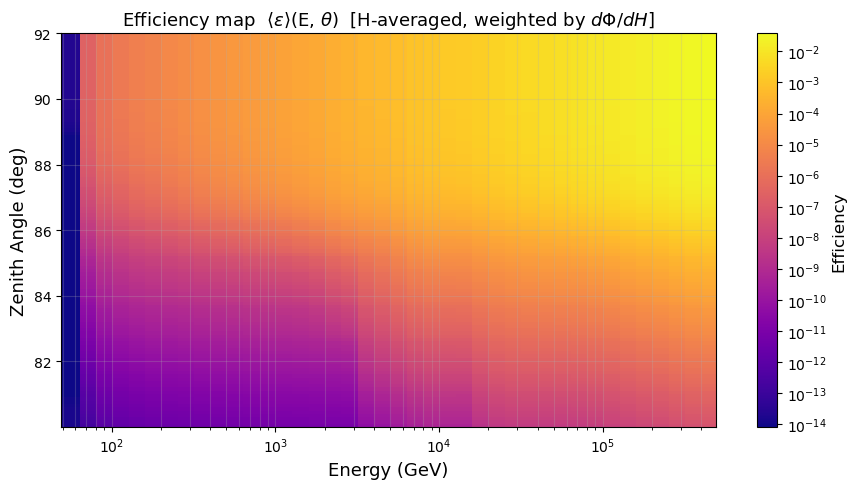

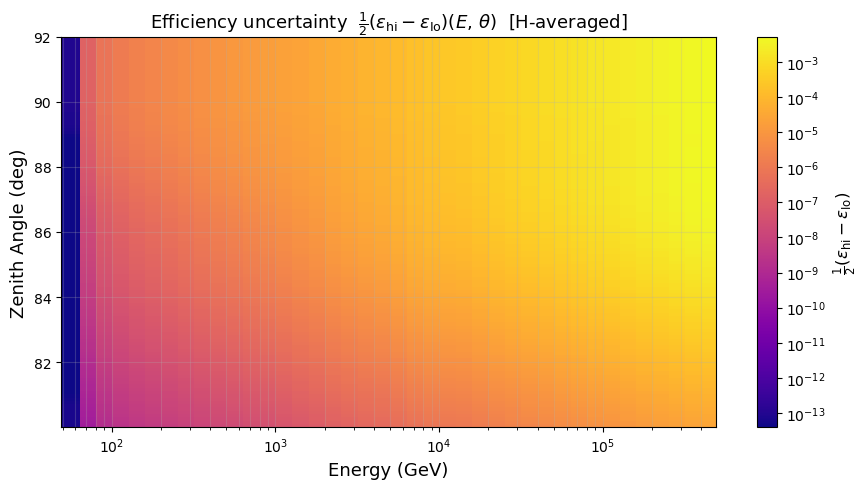

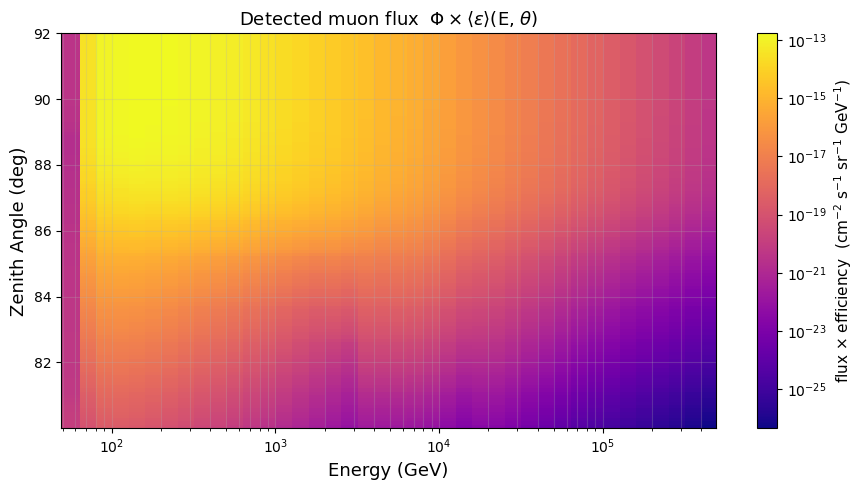

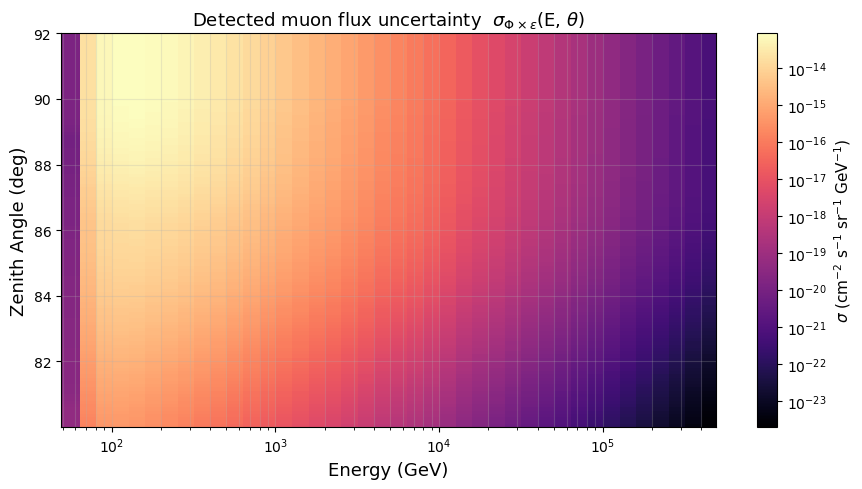

In [32]:
from matplotlib.colors import SymLogNorm

E_mask_plot = (E_GeV > 5e1) & (E_GeV < 5e5)

# =========================================================================
# Build flux_raw_map from selected_entries (shape: n_zen x n_E)
# Each entry['d_CDF'] has shape (n_H, n_E); sum over H axis to get per-E flux
# =========================================================================
flux_raw_map = np.full((len(selected_entries), len(E_GeV)), np.nan)
for i, entry in enumerate(selected_entries):
    d = entry['d_CDF']
    # d_CDF may be (n_H, n_E) or (n_E,) depending on MCEq grid structure
    flux_raw_map[i, :] = d.sum(axis=0) if d.ndim == 2 else d

# =========================================================================
# Efficiency asymmetric half-widths  (n_zen, n_E)
# =========================================================================
eff_map_err_lo = np.clip(eff_map - eff_map_lo, 0, None)   # downward uncertainty
eff_map_err_hi = np.clip(eff_map_hi - eff_map, 0, None)   # upward uncertainty
eff_map_err    = 0.5 * (eff_map_err_lo + eff_map_err_hi)  # symmetric mid-point for plotting

# Muon flux × efficiency
flux_x_eff_map     = flux_raw_map * eff_map      # (n_zen, n_E)
flux_x_eff_err_map = flux_raw_map * eff_map_err  # (n_zen, n_E)

# =========================================================================
# Helper to make a SymLogNorm safely
# =========================================================================
def _symlog_norm(data, fallback=1e-12):
    pos = data[np.isfinite(data) & (data > 0)]
    linthresh = pos.min() if pos.size else fallback
    return SymLogNorm(linthresh=linthresh, linscale=0.5, base=10)

# =========================================================================
# Plot 1: Efficiency map
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    eff_map[:, E_mask_plot],
    shading='auto',
    cmap='plasma',
    norm=_symlog_norm(eff_map[:, E_mask_plot]),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency map  $\langle\varepsilon\rangle$(E, $\theta$)'
             r'  [H-averaged, weighted by $d\Phi/dH$]', fontsize=13)
fig.colorbar(pcm, ax=ax).set_label('Efficiency', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# Plot 2: Efficiency uncertainty map  (symmetric half-width of CI)
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    eff_map_err[:, E_mask_plot],
    shading='auto',
    cmap='plasma',
    norm=_symlog_norm(eff_map_err[:, E_mask_plot]),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency uncertainty  '
             r'$\frac{1}{2}(\varepsilon_\mathrm{hi} - \varepsilon_\mathrm{lo})$'
             r'$(E,\,\theta)$  [H-averaged]', fontsize=13)
fig.colorbar(pcm, ax=ax).set_label(
    r'$\frac{1}{2}(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# Plot 3: Muon flux × efficiency map
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    flux_x_eff_map[:, E_mask_plot],
    shading='auto',
    cmap='plasma',
    norm=_symlog_norm(flux_x_eff_map[:, E_mask_plot]),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(
    r'Detected muon flux  $\Phi \times \langle\varepsilon\rangle$(E, $\theta$)',
    fontsize=13)
fig.colorbar(pcm, ax=ax).set_label(
    r'flux $\times$ efficiency  (cm$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$)',
    fontsize=11)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# Plot 4: Detected muon flux uncertainty map
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(
    E_GeV[E_mask_plot],
    zen_centers,
    flux_x_eff_err_map[:, E_mask_plot],
    shading='auto',
    cmap='magma',
    norm=_symlog_norm(flux_x_eff_err_map[:, E_mask_plot]),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Detected muon flux uncertainty  '
             r'$\sigma_{\Phi\times\varepsilon}$(E, $\theta$)', fontsize=13)
fig.colorbar(pcm, ax=ax).set_label(
    r'$\sigma$ (cm$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$)', fontsize=11)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()


In [28]:
import pickle

E_save_mask = (E_GeV >= 5e1) & (E_GeV <= 5e5)

eff_map_output = {
    'zen_centers':   zen_centers,
    'E_GeV':         E_GeV[E_save_mask],
    'H_grid':        selected_entries[0]['H_grid'],
    'eff_map':       eff_map[:, E_save_mask],
    'eff_map_lo':    eff_map_lo[:, E_save_mask],
    'eff_map_hi':    eff_map_hi[:, E_save_mask],
    'eff_map_err':   eff_map_err[:, E_save_mask],   # symmetric half-width
    'min_E':         1e2,
    'max_E':         5e5,
    'zen_range':     (zen_min_use, zen_max_use),
    'extend_to_deg': extend_to_deg,
}

out_path = '/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(eff_map_output, f)

print(f"Saved eff_map to {out_path}")
print(f"  E range:           {E_GeV[E_save_mask].min():.1e} – {E_GeV[E_save_mask].max():.1e} GeV  ({E_save_mask.sum()} bins)")
print(f"  eff_map shape:     {eff_map[:, E_save_mask].shape}")
print(f"  eff_map_lo shape:  {eff_map_lo[:, E_save_mask].shape}")
print(f"  eff_map_hi shape:  {eff_map_hi[:, E_save_mask].shape}")
print(f"  eff_map_err shape: {eff_map_err[:, E_save_mask].shape}")


Saved eff_map to /uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl
  E range:           5.6e+01 – 4.5e+05 GeV  (40 bins)
  eff_map shape:     (120, 40)
  eff_map_lo shape:  (120, 40)
  eff_map_hi shape:  (120, 40)
  eff_map_err shape: (120, 40)


Zenith bins: 120  (91.95° → 80.05°)
Energy bins: 40  (5.62e+01 → 4.47e+05 GeV)
eff_map shape:     (120, 40)
eff_map_lo shape:  (120, 40)
eff_map_hi shape:  (120, 40)
eff_map_err shape: (120, 40)


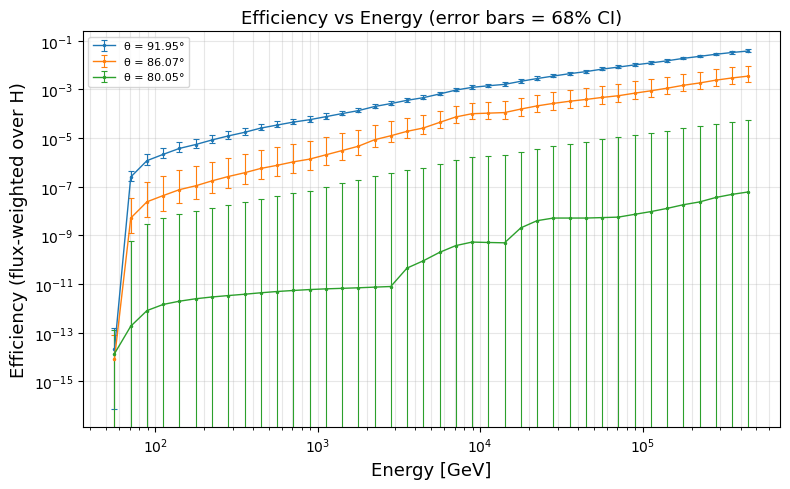

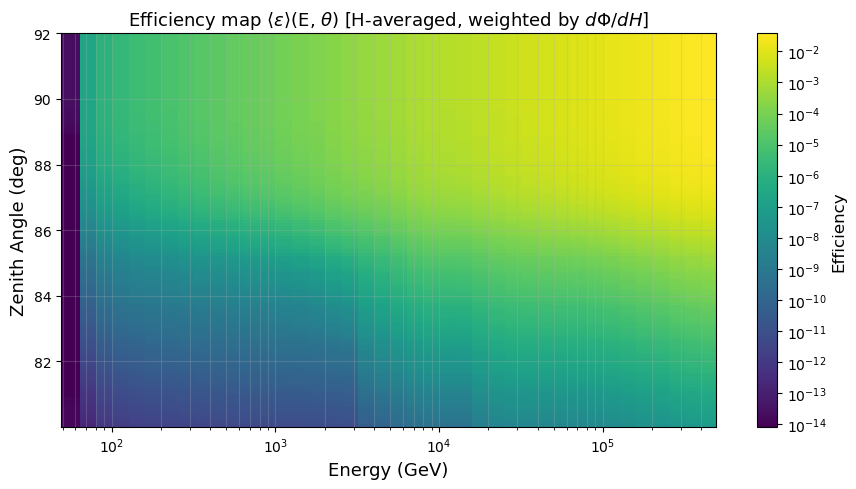

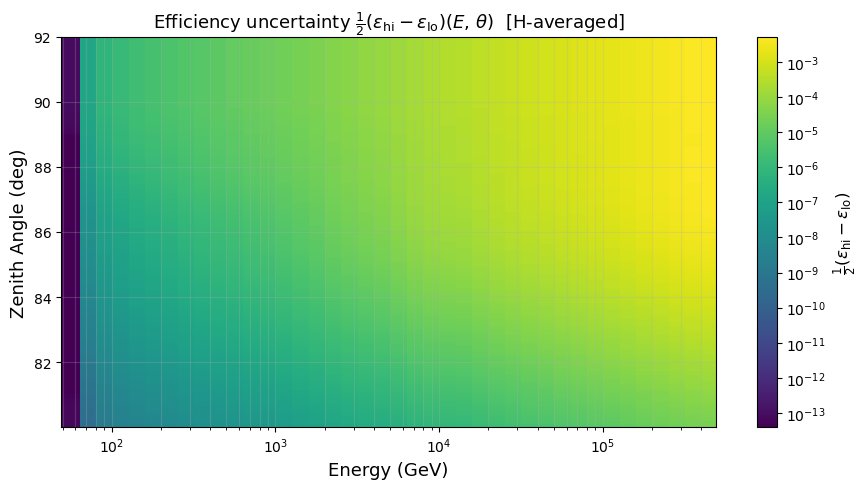

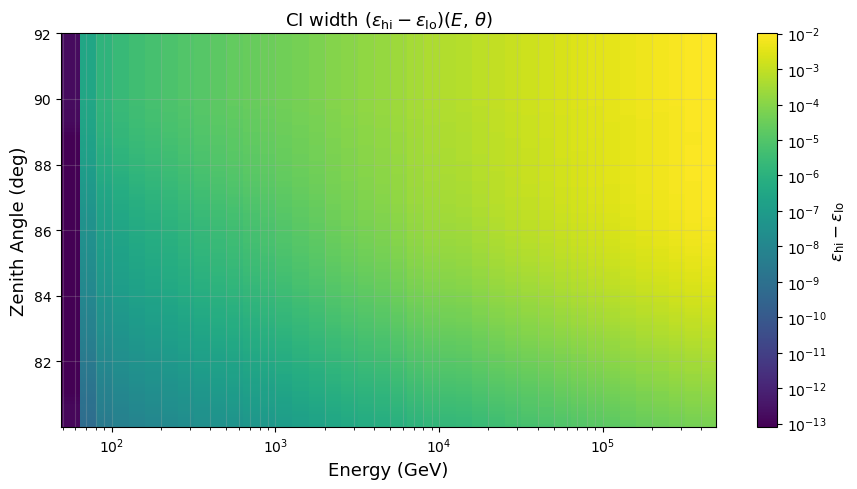

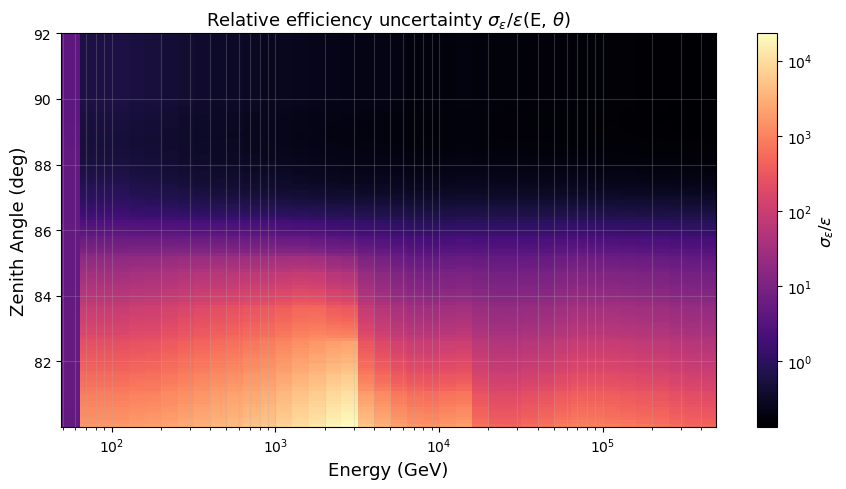

In [29]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

in_path = '/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/eff_map_80_92deg.pkl'

with open(in_path, 'rb') as f:
    data = pickle.load(f)

zen_centers = data['zen_centers']
E_GeV       = data['E_GeV']
eff_map     = data['eff_map']
eff_map_lo  = data['eff_map_lo']
eff_map_hi  = data['eff_map_hi']
eff_map_err = data['eff_map_err']   # symmetric half-width

# Asymmetric half-widths for error bars
err_lo = np.clip(eff_map - eff_map_lo, 0, None)  # downward
err_hi = np.clip(eff_map_hi - eff_map, 0, None)  # upward

print(f"Zenith bins: {len(zen_centers)}  ({zen_centers[0]:.2f}° → {zen_centers[-1]:.2f}°)")
print(f"Energy bins: {len(E_GeV)}  ({E_GeV[0]:.2e} → {E_GeV[-1]:.2e} GeV)")
print(f"eff_map shape:     {eff_map.shape}")
print(f"eff_map_lo shape:  {eff_map_lo.shape}")
print(f"eff_map_hi shape:  {eff_map_hi.shape}")
print(f"eff_map_err shape: {eff_map_err.shape}")

def _symlog_norm(data, fallback=1e-12):
    pos = data[np.isfinite(data) & (data > 0)]
    linthresh = pos.min() if pos.size else fallback
    return SymLogNorm(linthresh=linthresh, linscale=0.5, base=10)

# =========================================================================
# 1. Efficiency vs Energy (line plot with asymmetric error bands)
# =========================================================================
fig, ax = plt.subplots(figsize=(8, 5))
n_show = min(3, len(zen_centers))
idxs = np.linspace(0, len(zen_centers) - 1, n_show, dtype=int)
for i in idxs:
    ax.errorbar(
        E_GeV, eff_map[i],
        yerr=[err_lo[i], err_hi[i]],          # asymmetric CI
        label=f"θ = {zen_centers[i]:.2f}°",
        marker='.', markersize=3, linewidth=1,
        capsize=2, capthick=0.8, elinewidth=0.8,
    )
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Energy [GeV]', fontsize=13)
ax.set_ylabel('Efficiency (flux-weighted over H)', fontsize=13)
ax.set_title('Efficiency vs Energy (error bars = 68% CI)', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

# =========================================================================
# 2. Efficiency 2D heatmap
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(
    E_GeV, zen_centers, eff_map,
    shading='auto', cmap='plasma',
    norm=_symlog_norm(eff_map),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency map $\langle\varepsilon\rangle$(E, $\theta$) '
             r'[H-averaged, weighted by $d\Phi/dH$]', fontsize=13)
fig.colorbar(pcm, ax=ax).set_label('Efficiency', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# 3a. Efficiency uncertainty 2D heatmap  (symmetric half-width)
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))
pcm_err = ax.pcolormesh(
    E_GeV, zen_centers, eff_map_err,
    shading='auto', cmap='viridis',
    norm=_symlog_norm(eff_map_err),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Efficiency uncertainty $\frac{1}{2}(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$'
             r'$(E,\,\theta)$  [H-averaged]', fontsize=13)
fig.colorbar(pcm_err, ax=ax).set_label(
    r'$\frac{1}{2}(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# 3b. Asymmetric CI width: hi - lo
# =========================================================================
ci_width = np.clip(eff_map_hi - eff_map_lo, 0, None)
fig, ax = plt.subplots(figsize=(9, 5))
pcm_ci = ax.pcolormesh(
    E_GeV, zen_centers, ci_width,
    shading='auto', cmap='plasma',
    norm=_symlog_norm(ci_width),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'CI width $(\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo})$'
             r'$(E,\,\theta)$', fontsize=13)
fig.colorbar(pcm_ci, ax=ax).set_label(
    r'$\varepsilon_\mathrm{hi}-\varepsilon_\mathrm{lo}$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()

# =========================================================================
# 4. Relative uncertainty 2D heatmap  (sigma / eff)
# =========================================================================
rel_err = np.where(eff_map > 0, eff_map_err / eff_map, np.nan)

fig, ax = plt.subplots(figsize=(9, 5))
pcm_rel = ax.pcolormesh(
    E_GeV, zen_centers, rel_err,
    shading='auto', cmap='magma',
    norm=_symlog_norm(rel_err),
)
ax.set_xscale('log')
ax.set_xlabel(r'Energy (GeV)', fontsize=13)
ax.set_ylabel(r'Zenith Angle (deg)', fontsize=13)
ax.set_title(r'Relative efficiency uncertainty $\sigma_\varepsilon / \varepsilon$(E, $\theta$)',
             fontsize=13)
fig.colorbar(pcm_rel, ax=ax).set_label(
    r'$\sigma_\varepsilon / \varepsilon$', fontsize=12)
ax.grid(alpha=0.25, which='both')
fig.tight_layout()
plt.show()
